## Problem Statement

Student Name: Jonathan Brosnan

In [ ]:
!jupyter nbconvert --to html /content/EasyVisa_Full_Code_Notebook.ipynb

[NbConvertApp] Converting notebook /content/EasyVisa_Full_Code_Notebook.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 36 image(s).
[NbConvertApp] Writing 2440858 bytes to /content/EasyVisa_Full_Code_Notebook.html


### Business Context

Business communities in the United States are facing high demand for human resources, but one of the constant challenges is identifying and attracting the right talent, which is perhaps the most important element in remaining competitive. Companies in the United States look for hard-working, talented, and qualified individuals both locally as well as abroad.

The Immigration and Nationality Act (INA) of the US permits foreign workers to come to the United States to work on either a temporary or permanent basis. The act also protects US workers against adverse impacts on their wages or working conditions by ensuring US employers' compliance with statutory requirements when they hire foreign workers to fill workforce shortages. The immigration programs are administered by the Office of Foreign Labor Certification (OFLC).

OFLC processes job certification applications for employers seeking to bring foreign workers into the United States and grants certifications in those cases where employers can demonstrate that there are not sufficient US workers available to perform the work at wages that meet or exceed the wage paid for the occupation in the area of intended employment.

### Objective

In FY 2016, the OFLC processed 775,979 employer applications for 1,699,957 positions for temporary and permanent labor certifications. This was a nine percent increase in the overall number of processed applications from the previous year. The process of reviewing every case is becoming a tedious task as the number of applicants is increasing every year.

The increasing number of applicants every year calls for a Machine Learning based solution that can help in shortlisting the candidates having higher chances of VISA approval. OFLC has hired the firm EasyVisa for data-driven solutions. You as a data  scientist at EasyVisa have to analyze the data provided and, with the help of a classification model:

* Facilitate the process of visa approvals.
* Recommend a suitable profile for the applicants for whom the visa should be certified or denied based on the drivers that significantly influence the case status.

### Data Description

The data contains the different attributes of employee and the employer. The detailed data dictionary is given below.

* case_id: ID of each visa application
* continent: Information of continent the employee
* education_of_employee: Information of education of the employee
* has_job_experience: Does the employee has any job experience? Y= Yes; N = No
* requires_job_training: Does the employee require any job training? Y = Yes; N = No
* no_of_employees: Number of employees in the employer's company
* yr_of_estab: Year in which the employer's company was established
* region_of_employment: Information of foreign worker's intended region of employment in the US.
* prevailing_wage:  Average wage paid to similarly employed workers in a specific occupation in the area of intended employment. The purpose of the prevailing wage is to ensure that the foreign worker is not underpaid compared to other workers offering the same or similar service in the same area of employment.
* unit_of_wage: Unit of prevailing wage. Values include Hourly, Weekly, Monthly, and Yearly.
* full_time_position: Is the position of work full-time? Y = Full Time Position; N = Part Time Position
* case_status:  Flag indicating if the Visa was certified or denied

## Installing and Importing the necessary libraries

In [ ]:
# Installing the libraries with the specified version.
#!pip install numpy==2.3.4 pandas==1.5.3 scikit-learn==1.5.2 matplotlib==3.7.1 seaborn==0.13.1 xgboost plotly==5.17.0 imbalanced-learn -q --user
!pip install numpy==1.25.2 pandas==1.5.3 scikit-learn==1.5.2 matplotlib==3.7.1 seaborn==0.13.1 xgboost==2.0.3 plotly==5.17.0 imbalanced-learn -q --user

  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the below.*

In [ ]:
# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd
from typing import Any
from collections import Counter

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV

#Uncommented
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from xgboost import XGBClassifier

# libaries to help with data visualization
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 100)

from sklearn.tree import DecisionTreeClassifier
# Libraries different ensemble classifiers
from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    StackingClassifier
)



# Libraries to get different metric scores
from sklearn import metrics
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)



# To ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")



## Import Dataset

In [ ]:
#visa = pd.read_csv('E:\iCloud\Drive\iCloudDrive\Machine Learning Course\EasyVisa\EasyVisa.csv')
visa = pd.read_csv('/content/EasyVisa.csv')
df = visa.copy()

## Overview of the Dataset

#### View the first and last 5 rows of the dataset

In [ ]:
# Display the shape (number of rows and columns) of the dataset
print(f"Dataset shape: {df.shape}")
# Show the first 5 rows of the dataframe for a quick look at the data
print("\nFirst 5 rows:")
display(df.head(5))
# Show the last 5 rows of the dataframe for completeness
print("\nLast 5 rows:")
display(df.tail(5))
# Display data types of all columns in a tabular format for easier inspection
print("Data Types:")
data_types_df = pd.DataFrame({
    'Column Name': df.columns,
    'Data Type': df.dtypes.values
})
display(data_types_df)

Dataset shape: (25480, 12)

First 5 rows:


,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified



Last 5 rows:


,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.57,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.79,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.85,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.77,Year,Y,Certified
25479,EZYV25480,Asia,Bachelor's,Y,N,3195,1960,Midwest,70876.91,Year,Y,Certified


Data Types:


,Column Name,Data Type
0,case_id,object
1,continent,object
2,education_of_employee,object
3,has_job_experience,object
4,requires_job_training,object
5,no_of_employees,int64
6,yr_of_estab,int64
7,region_of_employment,object
8,prevailing_wage,float64
9,unit_of_wage,object


#### Checking for missing values, nulls and duplicates

In [ ]:
# Check for missing values using isna() and isnull() for each column
missing_isna = df.isna().sum()
missing_isnull = df.isnull().sum()

# Create a DataFrame to compare missing values by both methods side by side
missing_df = pd.DataFrame({
    'isna()': missing_isna,
    'isnull()': missing_isnull
})

# Display the DataFrame showing missing value counts for both methods
display(missing_df)

# Check for duplicated rows in the dataset
dups = df.duplicated().sum()

# Print the result of the duplicate check with an informative message
if dups:
    print(f"{dups} duplicate values were found.")
else:
    print("There are no duplicate values in the dataset.")


,isna(),isnull()
case_id,0,0
continent,0,0
education_of_employee,0,0
has_job_experience,0,0
requires_job_training,0,0
no_of_employees,0,0
yr_of_estab,0,0
region_of_employment,0,0
prevailing_wage,0,0
unit_of_wage,0,0


There are no duplicate values in the dataset.


## Exploratory Data Analysis (EDA)

#### Let's check the statistical summary of the data

In [ ]:
# Generate standard summary stats (count, unique, mean, median, std, min, max) for all columns and transpose for readability
#summary = df.agg(['count', 'nunique', 'mean', 'median', 'std', 'min', 'max']).T.round(2)
num_summary = df.select_dtypes(include=[np.number]).agg(['count', 'nunique', 'mean', 'median', 'std', 'min', 'max']).T.round(2)
obj_summary = df.select_dtypes(exclude=[np.number]).agg(['count', 'nunique']).T

# Combine (left join) numeric and object summaries
summary = pd.concat([num_summary, obj_summary], axis=0).sort_index()
# Add the most frequent value ("top") for each column
# If .mode() is empty (possible with all-NaN columns), use np.nan as fallback
top = df.apply(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)

# Add the frequency of the "top" value ("freq") for each column
# If .value_counts() is empty, insert np.nan as fallback
freq = df.apply(lambda x: x.value_counts().iloc[0] if not x.value_counts().empty else np.nan)

summary['top'] = top
summary['freq'] = freq

# Ensure 'min' and 'max' are only shown for numeric columns; otherwise display NaN
for col in ['min', 'max']:
    summary[col] = [
        value if pd.api.types.is_number(value) else np.nan
        if not isinstance(value, (int, float, np.integer, np.floating)) else value.T.round(2)
        for value in summary[col]
    ]

# Set the index name for clarity in the displayed DataFrame
summary.index.name = 'Columns'
# Show the summary table
display(summary.reset_index())




,Columns,count,nunique,mean,median,std,min,max,top,freq
0,case_id,25480.0,25480.0,NaN,NaN,NaN,NaN,NaN,EZYV01,1
1,case_status,25480.0,2.0,NaN,NaN,NaN,NaN,NaN,Certified,17018
2,continent,25480.0,6.0,NaN,NaN,NaN,NaN,NaN,Asia,16861
3,education_of_employee,25480.0,4.0,NaN,NaN,NaN,NaN,NaN,Bachelor's,10234
4,full_time_position,25480.0,2.0,NaN,NaN,NaN,NaN,NaN,Y,22773
5,has_job_experience,25480.0,2.0,NaN,NaN,NaN,NaN,NaN,Y,14802
6,no_of_employees,25480.0,7105.0,5667.04,2109.00,22877.93,-26.00,602069.00,183,18
7,prevailing_wage,25480.0,25454.0,74455.81,70308.21,52815.94,2.14,319210.27,100.66,2
8,region_of_employment,25480.0,5.0,NaN,NaN,NaN,NaN,NaN,Northeast,7195
9,requires_job_training,25480.0,2.0,NaN,NaN,NaN,NaN,NaN,N,22525


#### Changing negative values in no_of_employees to positive values

In [ ]:
# Make sure 'no_of_employees' column is of a numeric type
if not pd.api.types.is_numeric_dtype(df["no_of_employees"]):
    # Attempt to convert to numeric, coercing errors to NaN
    df["no_of_employees"] = pd.to_numeric(df["no_of_employees"], errors="coerce")

# Create a mask for negative values in 'no_of_employees'
neg_mask = df["no_of_employees"] < 0

# Count how many negative values are present
num_negatives = neg_mask.sum()

if num_negatives > 0:
    # Print a message about how many negatives will be converted
    print(f"Converting {num_negatives} negative values in 'no_of_employees' to positive.")
    # Convert negative values to positive using absolute value
    df.loc[neg_mask, "no_of_employees"] = df.loc[neg_mask, "no_of_employees"].abs()
else:
    # Print a message if there are no negative values
    print("No negative values found in 'no_of_employees'.")

Converting 33 negative values in 'no_of_employees' to positive.


#### Checking the uniqueness of the categorical variables

In [ ]:


# Create a list of all categorical columns (columns with 'object' dtype)
cat_cols = list[Any](df.select_dtypes(include="object").columns)

# Print header for summary
print("=" * 70)
print("Summary of Unique Value Counts for Categorical Columns")
print("=" * 70)

# Initialize variables to keep track of column with the highest frequency of any value
max_count = -1
max_col = 'NA'
max_val = 'NA'

# Loop through all categorical columns
for column in cat_cols:
    # Get the frequency counts of each unique value in the column
    value_counts = df[column].value_counts()
    print(f"\nColumn: {column}")
    print(value_counts)
    # Check if there are any non-empty value counts and more than one unique value
    if not value_counts.empty and value_counts.size > 1:
        curr_max_count = value_counts.iloc[0]
        # Update max_count/max_col/max_val if this count is bigger than previous max
        if curr_max_count > max_count:
            max_count = curr_max_count
            max_col = column
            max_val = value_counts.index[0]
        # Print which value has the highest count if that count is greater than 1
        if curr_max_count > 1:
            print(f"--> Highest count: '{value_counts.index[0]}' with {curr_max_count}")
        else:
            print("\nNo column has a highest count (Columns are empty, are , or NA).")
    else:
        # Handle columns with only one unique value or empty
        print("--> Highest count: NA")
    print("-" * 50)


Summary of Unique Value Counts for Categorical Columns

Column: case_id
case_id
EZYV25480    1
EZYV01       1
EZYV02       1
EZYV03       1
EZYV04       1
            ..
EZYV13       1
EZYV12       1
EZYV11       1
EZYV10       1
EZYV09       1
Name: count, Length: 25480, dtype: int64

No column has a highest count (Columns are empty, are , or NA).
--------------------------------------------------

Column: continent
continent
Asia             16861
Europe            3732
North America     3292
South America      852
Africa             551
Oceania            192
Name: count, dtype: int64
--> Highest count: 'Asia' with 16861
--------------------------------------------------

Column: education_of_employee
education_of_employee
Bachelor's     10234
Master's        9634
High School     3420
Doctorate       2192
Name: count, dtype: int64
--> Highest count: 'Bachelor's' with 10234
--------------------------------------------------

Column: has_job_experience
has_job_experience
Y    14802
N 

#### Dropping 'case_id' column

In [ ]:

# Check if the 'case_id' column exists in the dataframe
if 'case_id' in df.columns:
    # Drop the 'case_id' column as it is not needed for further analysis
    df = df.drop('case_id', axis=1)
    print("'case_id' column dropped.")
else:
    # Inform the user if the column is not present in the dataframe
    print("No 'case_id' column present to drop.")

# Display information about the dataframe after dropping the column
df.info()

'case_id' column dropped.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   continent              25480 non-null  object 
 1   education_of_employee  25480 non-null  object 
 2   has_job_experience     25480 non-null  object 
 3   requires_job_training  25480 non-null  object 
 4   no_of_employees        25480 non-null  int64  
 5   yr_of_estab            25480 non-null  int64  
 6   region_of_employment   25480 non-null  object 
 7   prevailing_wage        25480 non-null  float64
 8   unit_of_wage           25480 non-null  object 
 9   full_time_position     25480 non-null  object 
 10  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(8)
memory usage: 2.1+ MB


### Univariate Analysis

In [ ]:
def histogram_boxplot(data, feature, figsize=(15, 10), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (15,10))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [ ]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

#### Observations on education of employee

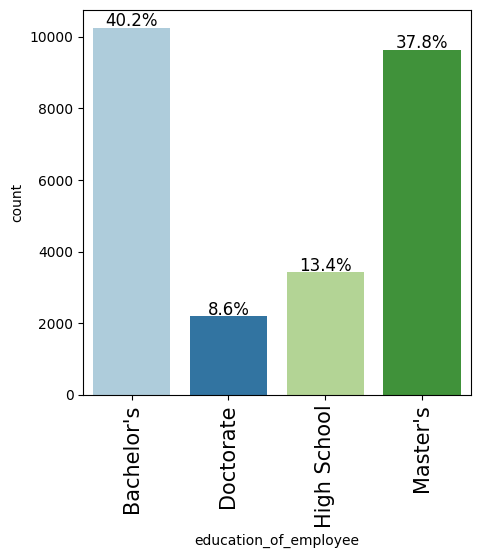

In [ ]:
labeled_barplot(df, "education_of_employee", perc=True)

#### Observations:
#### 1. The barplot above shows the percentage distribution of employees by their highest level of education.
#### 2. The majority of employees hold a Bachelor's degree, followed by those with a Master's degree.
#### 3. Employees with only a High School diploma or a Doctoral degree represent a much smaller proportion of the data.

#### Observations on region of employment

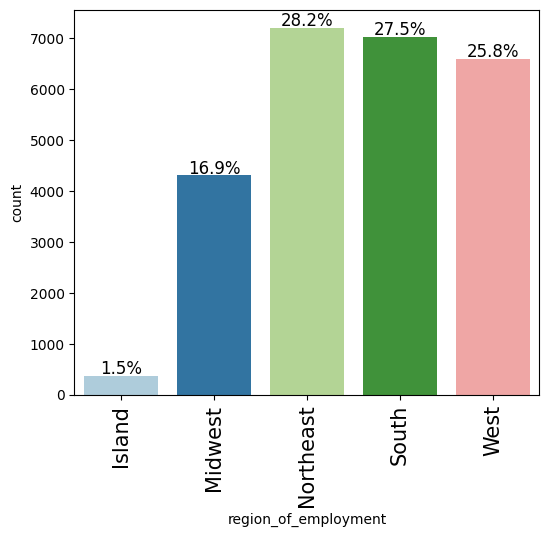

In [ ]:
labeled_barplot(df, "region_of_employment", perc=True)



#### Observations on Regional Employement:
#### 1. The Northeast region has the highest percentage of employment cases among all regions in the dataset.
#### 2. The West and South regions also account for a significant share, though less than the Northeast.
#### 3. The Midwest and other regions are less represented compared to the top regions.

#### Observations on job experience & job training

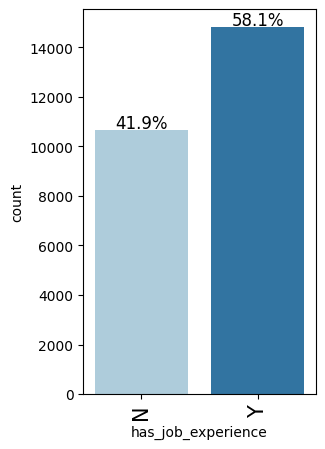

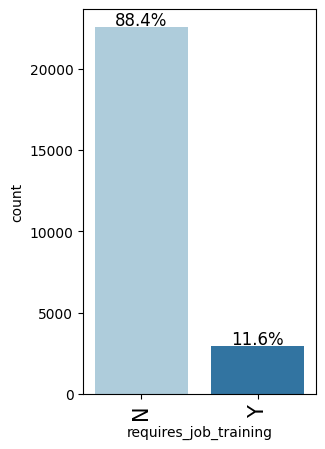

In [ ]:
labeled_barplot(df, "has_job_experience", perc=True)
labeled_barplot(df, "requires_job_training", perc=True)


#### Observations on Job Experience and Training Requirement:
#### 1. A large proportion of employees in the dataset have prior job experience.
#### 2. Most job openings do not require additional job training, indicating that employers may be seeking employees who are already equipped with the necessary skills.

#### Observations on case status

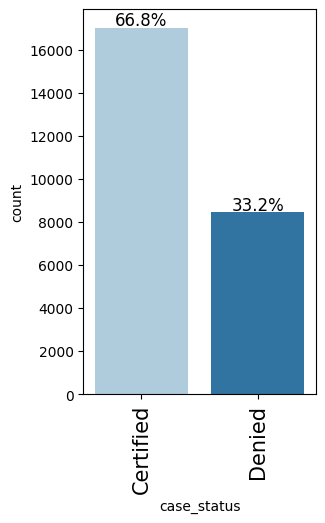

In [ ]:
labeled_barplot(df, "case_status", perc=True)

#### Observations on Case Status:
#### 1. The majority of cases in the dataset are "Certified"(1), comprising a significantly higher percentage than the "Denied"(0) cases.

#### Observations on job details(no_of_employees, prevailing_wage)

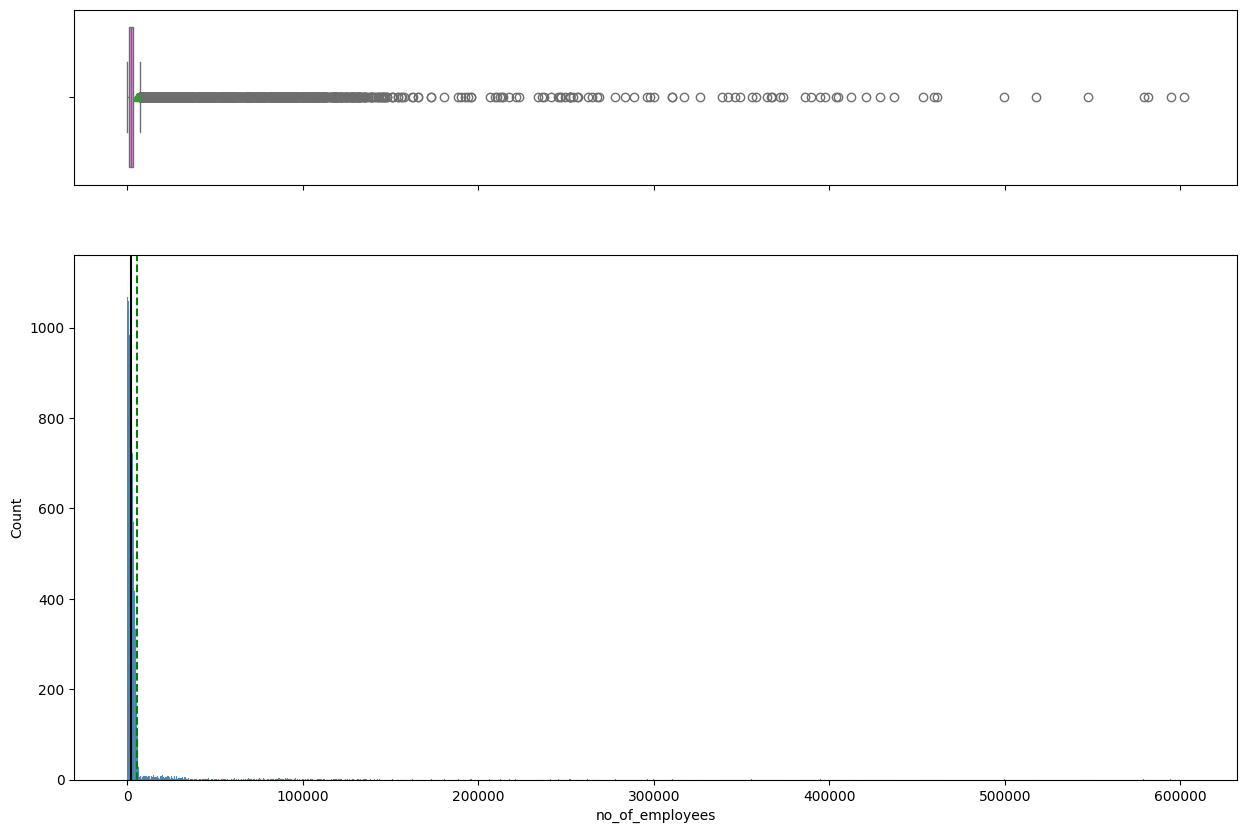

In [ ]:
histogram_boxplot(df,"no_of_employees")

#### Observations on No of Employees Distribution:
#### 1. There are noticeable outliers on the higher end, indicating some companies are exceptionally large compared to the majority.

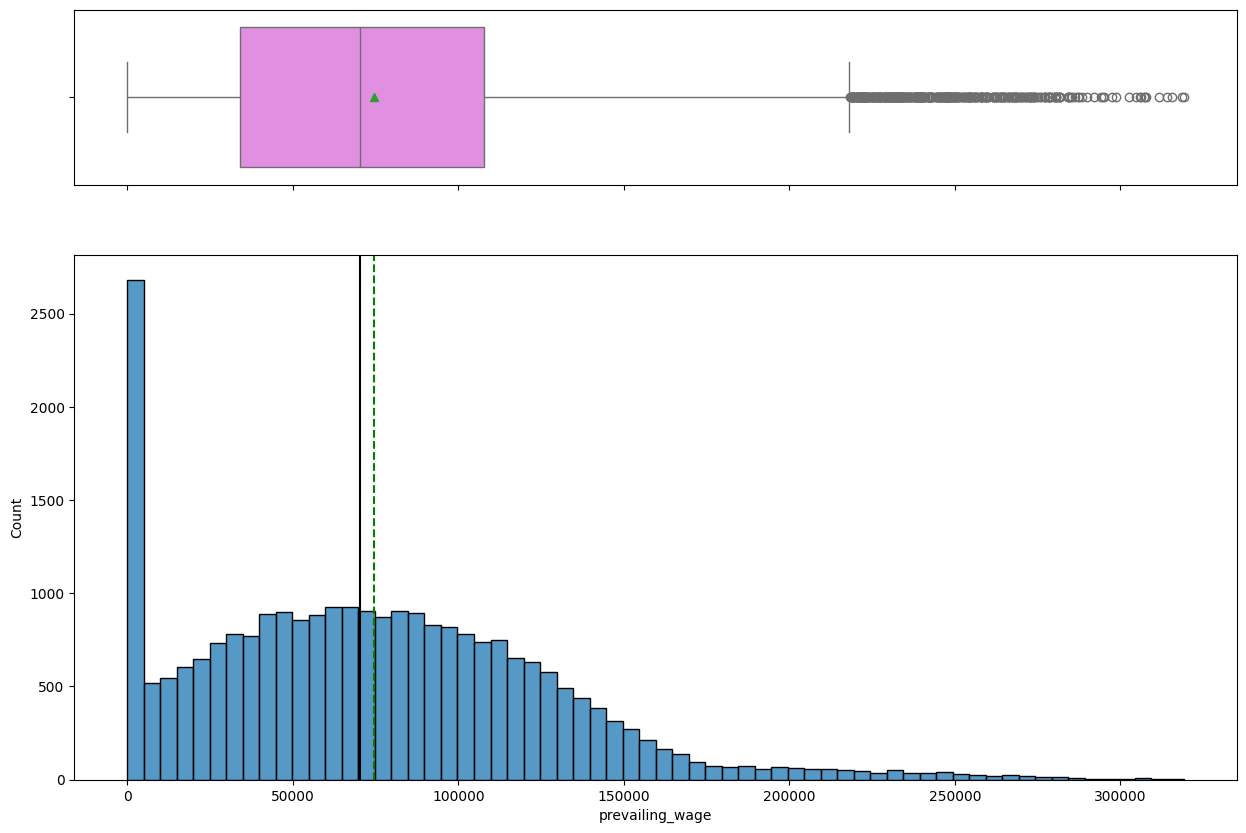

In [ ]:
histogram_boxplot(df,"prevailing_wage")

#### Observations on Prevailing Wage Distribution:
#### 1. The 'prevailing_wage' variable shows the majority of wages clustered at the lower end and a long tail of higher wage values.
#### 2. There are significant outliers present, indicating that a small number of positions are associated with very high prevailing wages.

### Bivariate Analysis

**Creating functions that will help us with further analysis.**

In [ ]:
### function to plot distributions wrt target


def distribution_plot_wrt_target(data, predictor, target):

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    target_uniq = data[target].unique()

    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="teal",
        stat="density",
    )

    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="orange",
        stat="density",
    )

    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")

    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        palette="gist_rainbow",
    )

    plt.tight_layout()
    plt.show()

In [ ]:
def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 5, 5))
    plt.legend(
        loc="lower left", frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

#### Does higher education increase the chances of visa certification for well-paid jobs abroad?

case_status            Certified  Denied   All
education_of_employee                         
All                         4372    1998  6370
Bachelor's                  1614     867  2481
Master's                    2128     540  2668
High School                  292     537   829
Doctorate                    338      54   392
------------------------------------------------------------------------------------------------------------------------


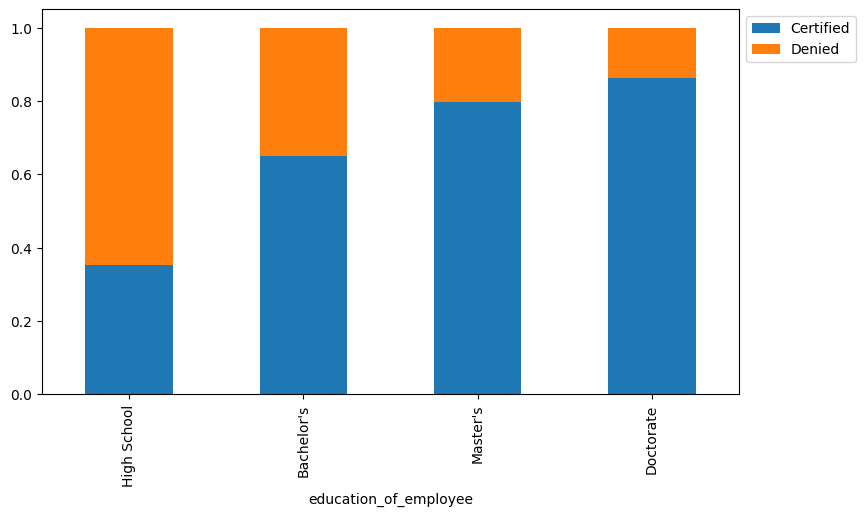

case_status,Certified,Denied
education_of_employee,,
High School,0.352232,0.647768
Bachelor's,0.650544,0.349456
Master's,0.797601,0.202399
Doctorate,0.862245,0.137755


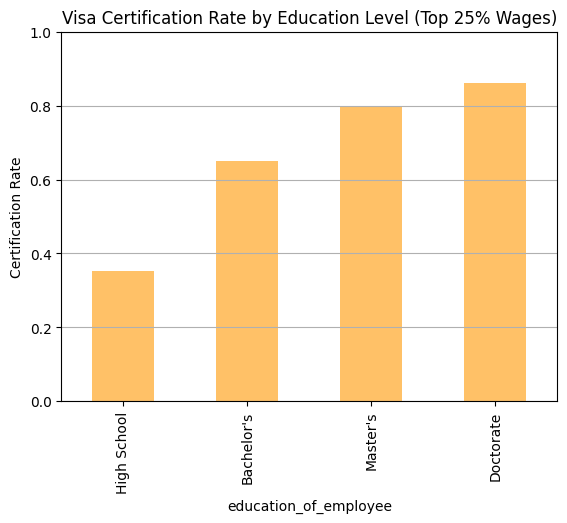

In [ ]:

# We'll define "well-paid jobs" as those in the top 25% (75th percentile) of prevailing wage.
high_wage_threshold = df["prevailing_wage"].quantile(0.75)
high_wage_df = df[df["prevailing_wage"] >= high_wage_threshold]



# Use the stacked_barplot function for a visual comparison
# It will show both the Certified and Denied proportions by education level
stacked_barplot(
    high_wage_df,
    predictor="education_of_employee",
    target="case_status"
)

# Calculate and display certification rate by education level for well-paid jobs, displaying specific education order
edu_order = ["High School", "Bachelor's", "Master's", "Doctorate"]
edu_cert_rates = (
    high_wage_df.groupby("education_of_employee")["case_status"]
    .value_counts(normalize=True)
    .unstack()
    .fillna(0)
    .rename(columns={1: "Certified", 0: "Denied"})
    .reindex(edu_order)
)
display(edu_cert_rates)


# Plot the certification rate by education for high-paying jobs,
# ensuring the display order is: High School, Bachelor's, Master's, Doctorate
edu_order = ["High School", "Bachelor's", "Master's", "Doctorate"]
edu_cert_rates_ordered = edu_cert_rates.loc[edu_order]

edu_cert_rates_ordered["Certified"].plot(kind="bar", color="#FFA726", alpha=0.7)
plt.ylabel("Certification Rate")
plt.title("Visa Certification Rate by Education Level (Top 25% Wages)")
plt.ylim(0, 1)
plt.grid(axis="y")
plt.show()

#### Answer:

#### As shown in the visualization and the table above for jobs in the top 25% of wages:
#### - Applicants with only a high school education have much lower certification rates compared to those with higher degrees.
#### - The certification rate rises consistently with more advanced educational qualifications, with doctorate and master's degree holders enjoying the highest certification rates.

#### Yes, higher education does increase the chances of visa certification for well-paid jobs abroad.

#### How does visa status vary across different continents?

case_status    Certified  Denied    All
continent                              
All                17018    8462  25480
Asia               11012    5849  16861
North America       2037    1255   3292
Europe              2957     775   3732
South America        493     359    852
Africa               397     154    551
Oceania              122      70    192
------------------------------------------------------------------------------------------------------------------------


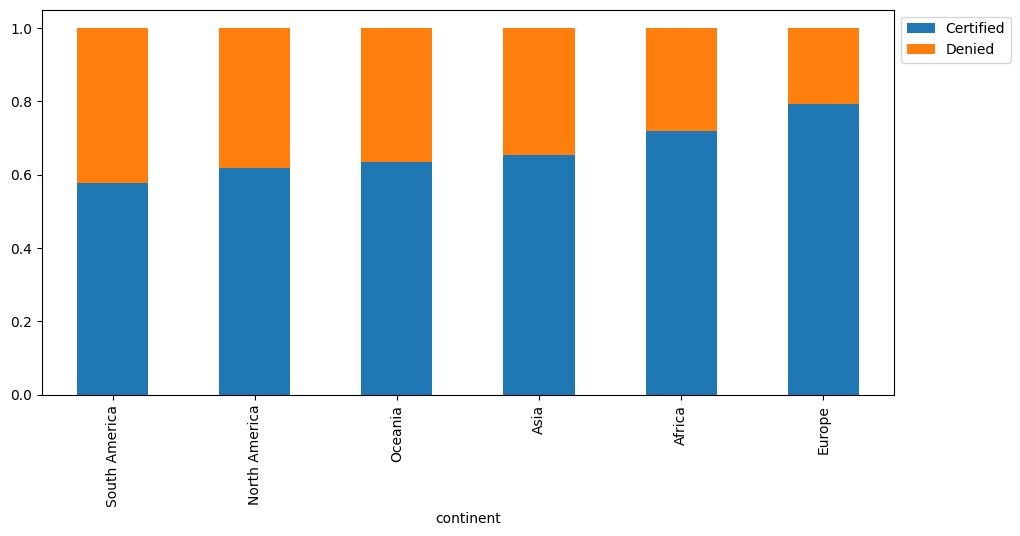

case_status,Certified,Denied
continent,,
South America,0.578638,0.421362
North America,0.618773,0.381227
Oceania,0.635417,0.364583
Asia,0.653105,0.346895
Africa,0.720508,0.279492
Europe,0.792337,0.207663


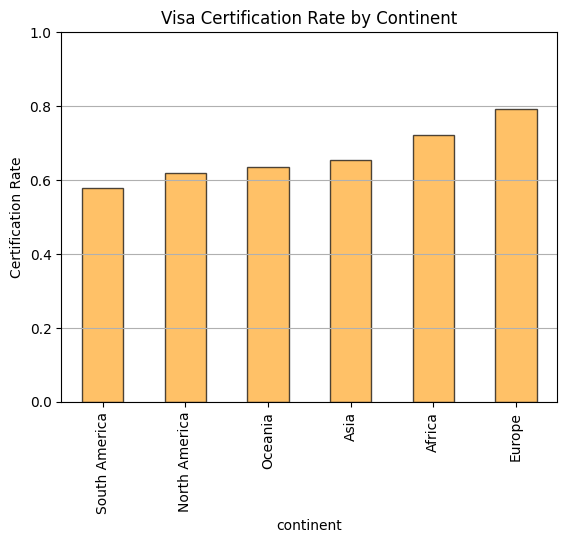

In [ ]:
stacked_barplot(
    df,
    predictor="continent",
    target="case_status"
)

# Calculate certification rates by continent
continent_cert_rates = (
    df.groupby("continent")["case_status"]
    .value_counts(normalize=True)
    .unstack()
    .fillna(0)
    .rename(columns={1: "Certified", 0: "Denied"})
)

continent_order = ['South America', 'North America', 'Oceania', 'Asia', 'Africa', 'Europe']
continent_cert_rates = continent_cert_rates.reindex(continent_order)

display(continent_cert_rates)

# Plot certification rate by continent in the matched order
continent_cert_rates["Certified"].plot(
    kind="bar",
    color="#FFA726",
    alpha=0.7,
    edgecolor='black'
)
plt.ylabel("Certification Rate")
plt.title("Visa Certification Rate by Continent")
plt.ylim(0, 1)
plt.grid(axis="y")
plt.show()

#### Answer:

#### Europe and Africa display the highest certification rates, with Europe notably leading, while Asia and Oceania are somewhat in the middle. North and South America have the lower certification rates with South America having the lowest.

#### Does having prior work experience influence the chances of visa certification for career opportunities abroad?

case_status         Certified  Denied    All
has_job_experience                          
All                     17018    8462  25480
N                        5994    4684  10678
Y                       11024    3778  14802
------------------------------------------------------------------------------------------------------------------------


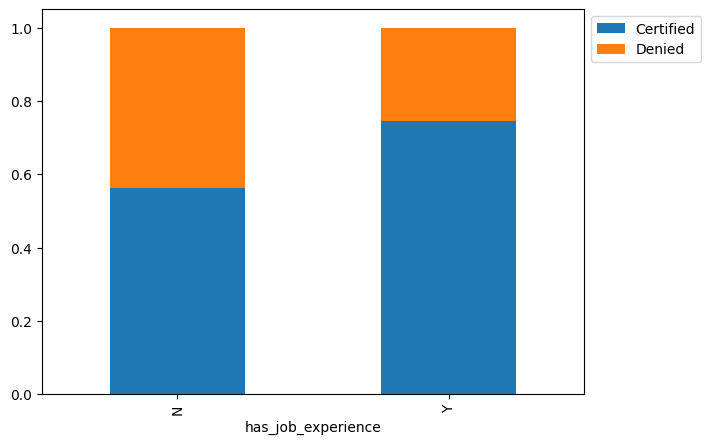

case_status,Certified,Denied
has_job_experience,,
N,0.561341,0.438659
Y,0.744764,0.255236


In [ ]:
stacked_barplot(
    df,
    predictor="has_job_experience",
    target="case_status"
)

# Calculate and display certification rates based on prior work experience
experience_cert_rates = (
    df.groupby("has_job_experience")["case_status"]
    .value_counts(normalize=True)
    .unstack()
    .fillna(0)
    .rename(columns={1: "Certified", 0: "Denied"})
)

display(experience_cert_rates)

#### Answer:

#### The graphs above demonstrate that having prior work experience significantly increases the chances of visa certification. As shown in the stacked bar plot and corresponding table, applicants with prior job experience ("Y") have a much higher certification rate than those without ("N"). Specifically, individuals with work experience show a certification rate of approximately 74%, while those without experience have a much lower rate, just over 56%. This clearly indicates that prior work experience positively influences the likelihood of receiving visa certification for career opportunities abroad.

#### Is the prevailing wage consistent across all regions of the US?

,count,mean,median,std,min,max
region_of_employment,,,,,,
Island,375,91712.750760,90678.17,53836.058580,52.8246,289878.68
Midwest,4307,91696.741794,89153.91,54561.011980,20.1896,319210.27
South,7017,74040.545216,70191.52,52468.450790,2.9561,306206.67
West,6586,69832.628698,64358.44,50638.413464,10.1111,314156.06
Northeast,7195,67872.662819,63276.51,51561.436157,2.1367,318446.05


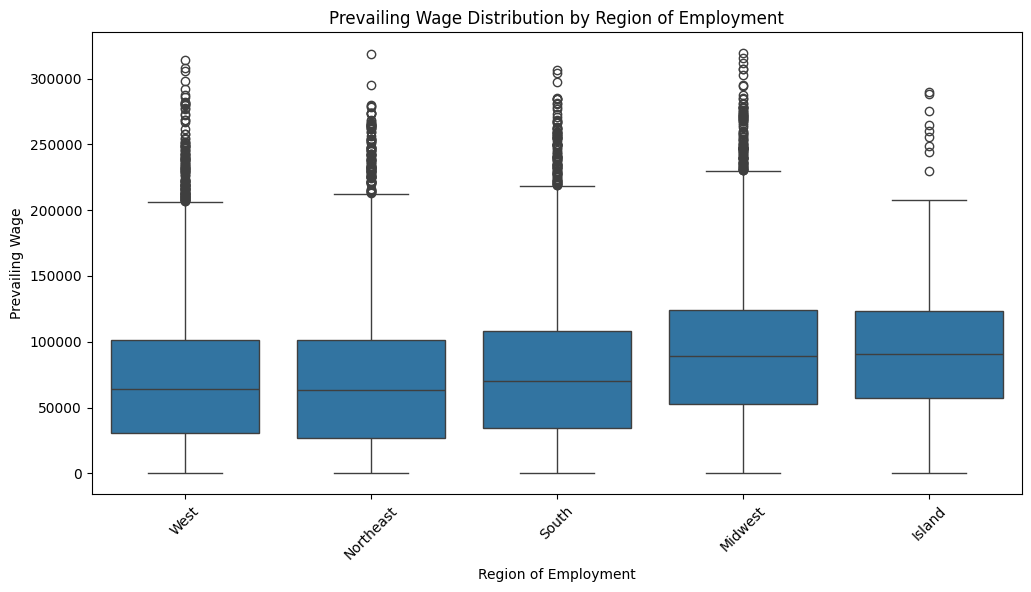

In [ ]:

# Show summary statistics of prevailing wage for each region to assess consistency
region_wage_stats = (
    df.groupby("region_of_employment")["prevailing_wage"]
    .agg(['count', 'mean', 'median', 'std', 'min', 'max'])
    .sort_values("mean", ascending=False)
)
display(region_wage_stats)

# Also, visualize prevailing wage distribution across regions
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df,
    x="region_of_employment",
    y="prevailing_wage"
)
plt.xticks(rotation=45)
plt.title("Prevailing Wage Distribution by Region of Employment")
plt.ylabel("Prevailing Wage")
plt.xlabel("Region of Employment")
plt.show()

#### Answer:

#### There are significant differences in both the mean, min, and median of prevailing wages between regions. Thus, regional differences play a significant role in determining the prevailing wage for visa applications.

#### Does visa status vary with changes in the prevailing wage set to protect both local talent and foreign workers?

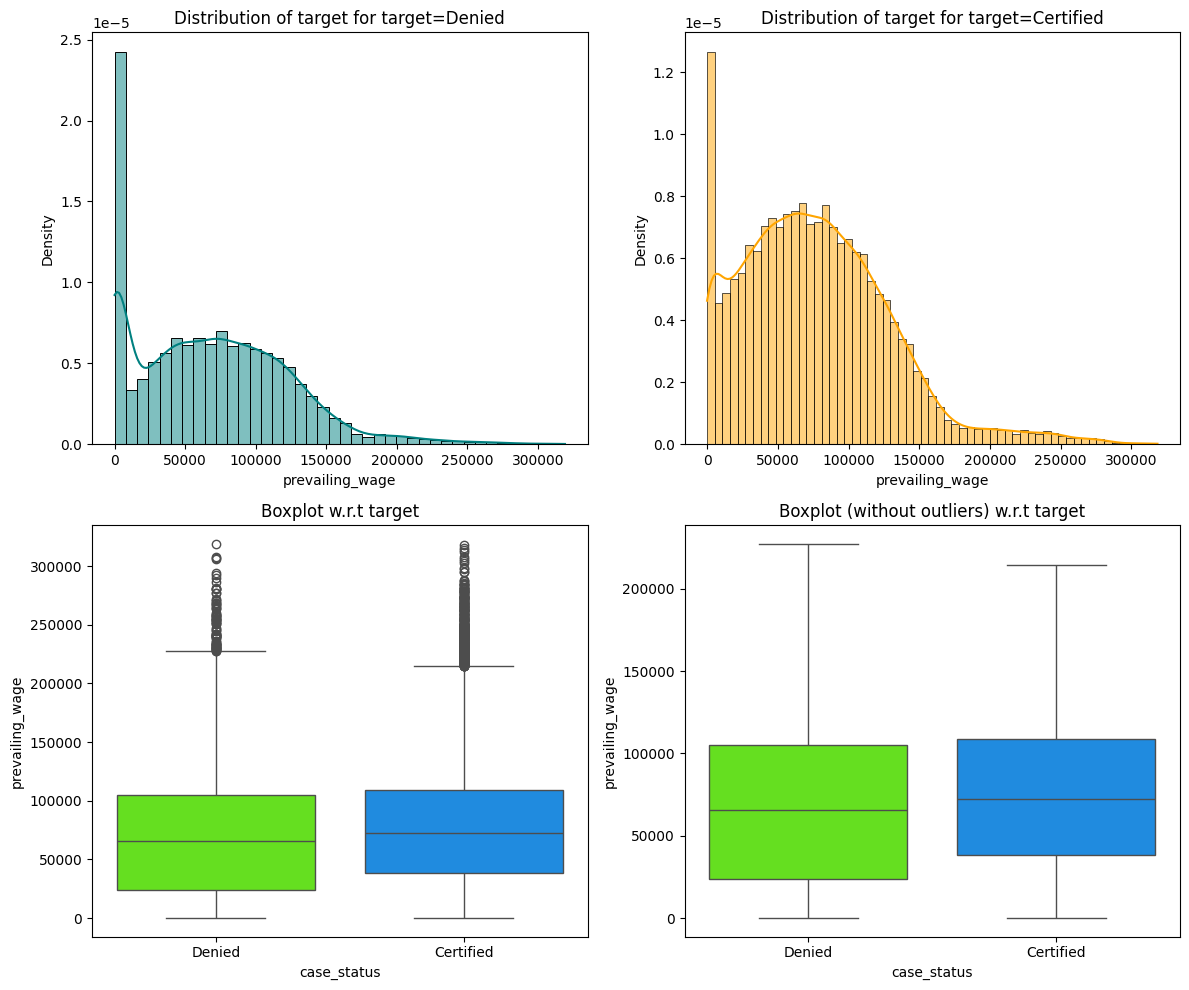

,count,mean,median,std,min,max
case_status,,,,,,
Certified,17018,77293.619243,72486.27,52042.715576,2.1367,318446.05
Denied,8462,68748.681580,65431.46,53890.166031,2.9561,319210.27


In [ ]:
distribution_plot_wrt_target(
    df,
    predictor="prevailing_wage",
    target="case_status"
)

prevailing_wage_by_status = df.groupby("case_status")["prevailing_wage"].agg(["count", "mean", "median", "std", "min", "max"])
display(prevailing_wage_by_status)





#### Answer:

#### The distribution_plot_wrt_target function and summary table reveal that certified applications typically have a higher mean and median prevailing wage compared to denied ones. This indicates that higher prevailing wages improve the likelihood of visa certification, supporting the idea that wage levels influence application outcomes.

#### Does the unit of prevailing wage (Hourly, Weekly, etc.) have any impact on the likelihood of visa application certification?

case_status   Certified  Denied    All
unit_of_wage                          
All               17018    8462  25480
Year              16047    6915  22962
Hour                747    1410   2157
Week                169     103    272
Month                55      34     89
------------------------------------------------------------------------------------------------------------------------


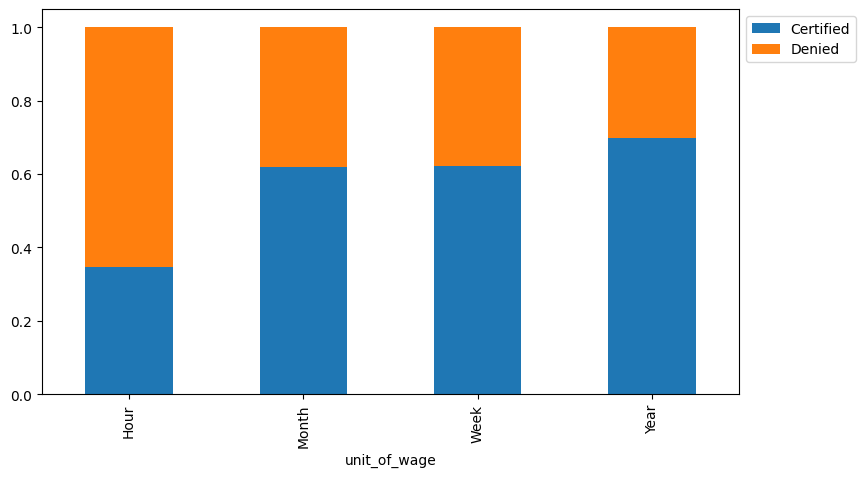

case_status,Certified,Denied
unit_of_wage,,
Hour,0.346314,0.653686
Month,0.617978,0.382022
Week,0.621324,0.378676
Year,0.698850,0.301150


In [ ]:
stacked_barplot(
    df,
    predictor="unit_of_wage",
    target="case_status"
)


unit_certification = pd.crosstab(df['unit_of_wage'], df['case_status'], normalize='index')
display(unit_certification)



#### Answer:

#### Based on the data provided above, it is clear that the unit of prevailing wage does impact visa certification likelihood. Applications with wages quoted by "Year", "Month", and "Week" have higher certification rates(\~60%-70%) compared to those quoted by "Hour" which have a much lower certification rate (~35%). This shows that applicants with annual, monthly, and weekly wage offers are more likely to be certified, while hourly wages are more likely to be denied.

## Data Pre-processing

### Outlier Check

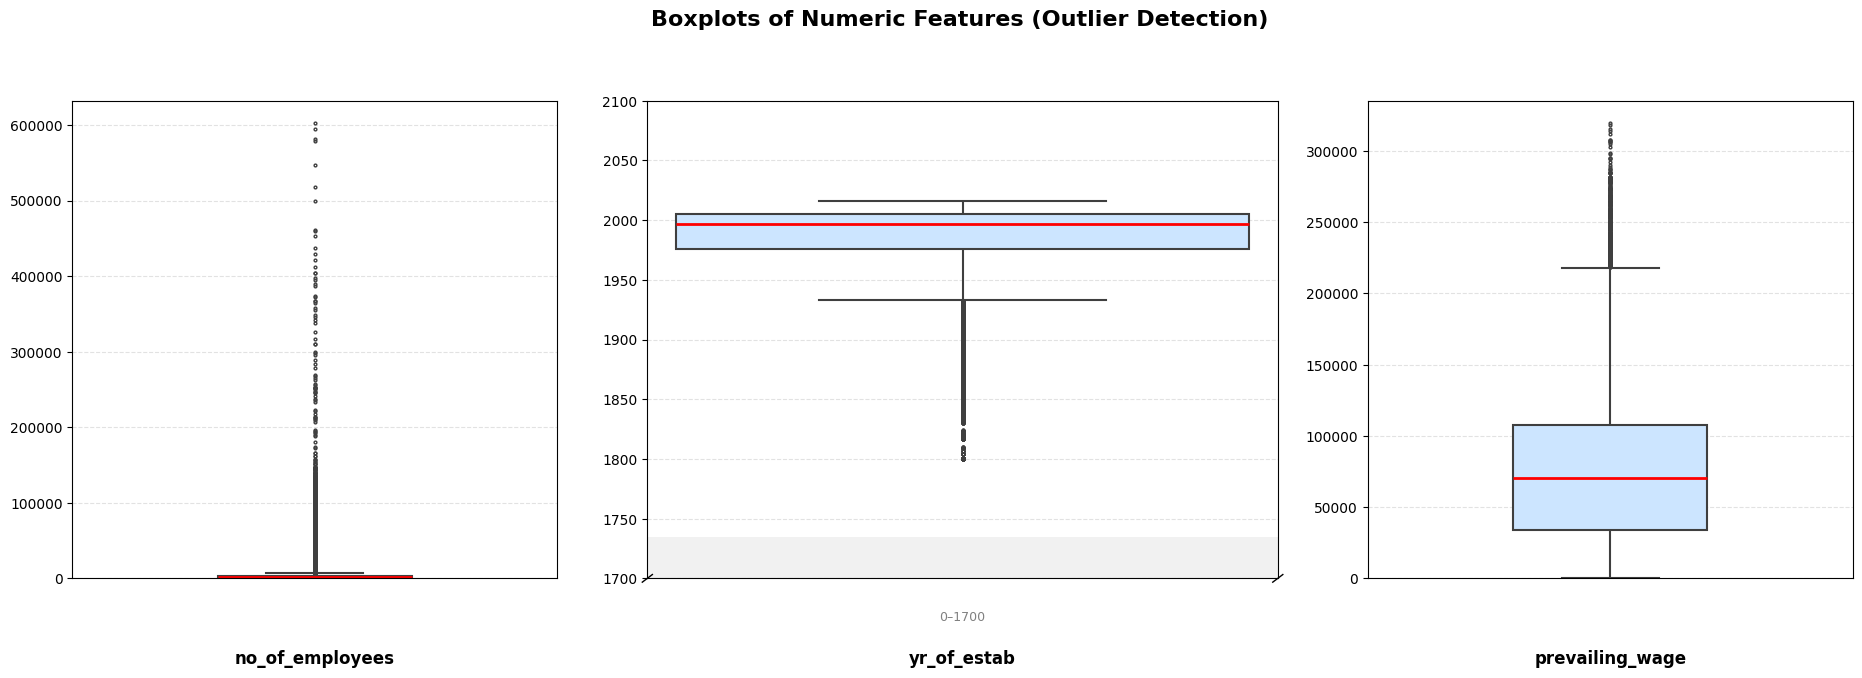

In [ ]:
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()
num_cols = len(numeric_columns)

n_cols = 3  # 3 boxplots in one row
n_rows = 1

fig, axes = plt.subplots(
    nrows=n_rows,
    ncols=n_cols,
    figsize=(6.3 * n_cols, 6.2),
    gridspec_kw={'width_ratios': [1, 1.3, 1]}
)

if n_cols == 1:
    axes = [axes]
elif n_cols > 1 and not isinstance(axes, (list, np.ndarray)):
    axes = [axes]

for i, varname in enumerate(numeric_columns):
    ax = axes[i]
    # Plot boxplot
    sns.boxplot(
        y=df[varname],
        ax=ax,
        color="#1f77b4",
        width=0.4,
        fliersize=2,
        linewidth=1.5,
        boxprops=dict(facecolor='#cce5ff'),
        medianprops=dict(color='r', linewidth=2),
    )
    # Remove title, y label, custom x label at bottom
    ax.set_title("")
    ax.set_ylabel("")
    ax.set_xticks([])
    ax.set_xlabel(
        varname,
        fontsize=12, weight='bold', labelpad=15
    )
    ax.xaxis.set_label_coords(0.5, -0.15)
    ax.grid(axis='y', linestyle="--", alpha=0.36)
    # Start y-axis at 0 unless customized
    if varname == "yr_of_estab":
        # axes break
        # Main visible: 1700-2100, show break at 1700
        ax.set_ylim(1700, 2100)
        # Add break indicator (zigzag) at the bottom-left and bottom-right of the plot
        d = 0.008  # size of diagonal lines in axes coords
        kwargs = dict(transform=ax.transAxes, color='k', clip_on=False, linewidth=1)
        ax.plot((-d, +d), (-d, +d), **kwargs)        # bottom-left diagonal
        ax.plot((1 - d, 1 + d), (-d, +d), **kwargs)  # bottom-right diagonal

        # Add label for break
        ax.annotate(
            '0–1700', xy=(0.5, 0), xycoords=('axes fraction', 'axes fraction'),
            xytext=(0, -23), textcoords='offset points',
            ha='center', va='top', fontsize=9, color='gray'
        )
        # Optionally, shade the skipped area with a patch
        ax.add_patch(mpatches.Rectangle(
            (-0.3, 1700), width=1.6, height=35, facecolor='gray', alpha=0.11,
            transform=ax.get_yaxis_transform(), zorder=0)
        )
    elif i == 1:
        # Middle variable, expand range; avoid extreme outliers
        col_data = df[varname]
        max_val = col_data.quantile(0.995)
        min_val = col_data.min()
        ax.set_ylim(min(0, min_val), max_val * 1.07)
    else:
        # Default: y starts at 0
        min_val = df[varname].min()
        ax.set_ylim(bottom=0 if min_val > 0 else min_val)

plt.tight_layout(pad=1.7)

# Center a single title above the middle axis (axes[1])
middle_ax = axes[1]
title_x = (middle_ax.get_position().x0 + middle_ax.get_position().x1) / 2

fig.suptitle(
    "Boxplots of Numeric Features (Outlier Detection)",
    fontsize=16, y=1.10, weight='bold', ha='center', x=0.515
)

plt.show()

### Data Preparation for modeling

In [ ]:

# Check if 'case_status' column exists before proceeding
if 'case_status' in df.columns and not pd.api.types.is_numeric_dtype(df['case_status']):

    # Encode 'case_status' to binary (1 = 'Certified', 0 = otherwise)
    df["case_status"] = df["case_status"].apply(lambda x: 1 if x == "Certified" else 0)
    #df["case_status"] = df["case_status"].eq("Certified").astype(int)
    # Display first 5 rows with 'case_status' column placed before 'continent'
    cols = list(df.columns)
    if cols.index('case_status') > cols.index('continent'):
        # Remove 'case_status' and reinsert before 'continent'
        cols.remove('case_status')
        continent_idx = cols.index('continent')
        cols = cols[:continent_idx] + ['case_status'] + cols[continent_idx:]
    print("Encoded 'case_status' to binary (1 = 'Certified', 0 = otherwise)")
    display(df[cols].head())

else:
    print("Column 'case_status' already encoded. Skipping to splitting steps.")
    display(df.head())

# Separate features (X) and target (Y)
X = df.drop('case_status', axis=1)
Y = df['case_status']

# If 'case_status' is not present as a numeric column (i.e., encoding failed), nullify the feature and target variables to prevent further errors
if not ('case_status' in df.columns and pd.api.types.is_numeric_dtype(df['case_status'])):
    X = None
    Y = None

X = pd.get_dummies(X, drop_first=True)

#Split the dataset into train and valid with a ratio of 7:3
x_train, x_val, y_train, y_val = train_test_split(X, Y, test_size=0.3, random_state=1, stratify=Y)

#Split the dataset into valid and test with a ratio of 9:1
x_val, x_test, y_val, y_test = train_test_split(x_val, y_val, test_size=0.1, random_state=1, stratify=y_val)


print("{0:0.2f}% of the data is in the training set.".format((len(x_train)/len(df.index)) * 100))
print("{0:0.2f}% of the data is in the validation set.".format((len(x_val)/len(df.index)) * 100))
print("{0:0.2f}% of the data is in the test set.".format((len(x_test)/len(df.index)) * 100))


Encoded 'case_status' to binary (1 = 'Certified', 0 = otherwise)


,case_status,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position
0,0,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y
1,1,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y
2,0,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y
3,0,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y
4,1,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y


70.00% of the data is in the training set.
27.00% of the data is in the validation set.
3.00% of the data is in the test set.


In [ ]:
# Print the shape and class balance of the Training set
print("Shape of Training set : ", x_train.shape)
print("Percentage of classes in training set:")
print(y_train.value_counts(normalize=True))
print('\n')

# Print the shape and class balance of the Validation set
print("Shape of Validation set : ", x_val.shape)
print("Percentage of classes in validation set:")
print(y_val.value_counts(normalize=True))
print('\n')

# Print the shape and class balance of the Test set
print("Shape of Testing set : ", x_test.shape)
print("Percentage of classes in test set:")
print(y_test.value_counts(normalize=True))
print('\n')

Shape of Training set :  (17836, 21)
Percentage of classes in training set:
case_status
1    0.667919
0    0.332081
Name: proportion, dtype: float64


Shape of Validation set :  (6879, 21)
Percentage of classes in validation set:
case_status
1    0.66783
0    0.33217
Name: proportion, dtype: float64


Shape of Testing set :  (765, 21)
Percentage of classes in test set:
case_status
1    0.667974
0    0.332026
Name: proportion, dtype: float64




## Model Building

### Model Evaluation Criterion

- Choose the primary metric to evaluate the model on
- Elaborate on the rationale behind choosing the metric

First, let's create functions to calculate different metrics and confusion matrix so that we don't have to use the same code repeatedly for each model.
* The `model_performance_classification_sklearn` function will be used to check the model performance of models.
* The `confusion_matrix_sklearn` function will be used to plot the confusion matrix.

In [ ]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn


def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [ ]:
def confusion_matrix_sklearn(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

#### Defining scorer to be used for cross-validation and hyperparameter tuning

In [ ]:

# Measures overall correctness of predictions
scorer_accuracy = metrics.make_scorer(metrics.accuracy_score)
# Measures proportion of true positives identified (sensitivity)
scorer_recall = metrics.make_scorer(metrics.recall_score)
# Measures proportion of predicted positives that are correct
scorer_precision = metrics.make_scorer(metrics.precision_score)
# Measures harmonic mean of precision and recall (balance between both)
scorer_f1 = metrics.make_scorer(metrics.f1_score)



**We are now done with pre-processing and evaluation criterion, so let's start building the model.**

### Model building with Original data

In [ ]:
# Define models with readable names in a list of tuples
models = [
    ("Bagging", BaggingClassifier(random_state=1)),
    ("Random Forest", RandomForestClassifier(random_state=1)),
    ("Gradient Boosting", GradientBoostingClassifier(random_state=1)),
    ("AdaBoost", AdaBoostClassifier(random_state=1)),
    ("Xgboost", XGBClassifier(random_state=1, eval_metric="logloss")),
    ("Decision Tree", DecisionTreeClassifier(random_state=1))
]

scoring_strategies = [
    ("F1 Score", scorer_f1, f1_score),
    ("Precision", scorer_precision, precision_score),
    ("Recall", scorer_recall, recall_score),
    ("Accuracy", scorer_accuracy, accuracy_score)
]

# Use the same StratifiedKFold split object for reproducibility
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

cv_results_all = {}
val_results_all = {}

for scorer_name, scorer, metric_func in scoring_strategies:
    print(f"\nCross-Validation performance on original training dataset ({scorer_name}):\n")
    cv_results = []
    scoring_names = []
    for name, model in models:
        cv_scores = cross_val_score(
            estimator=model,
            X=x_train,
            y=y_train,
            scoring=scorer,
            cv=kfold,
            n_jobs=-1
        )
        cv_results.append(cv_scores)
        scoring_names.append(name)
        print(f"{name}: {cv_scores.mean():.4f} (std: {cv_scores.std():.4f})")
    cv_results_all[scorer_name] = (scoring_names.copy(), [arr.copy() for arr in cv_results])

    print(f"\nValidation Performance({scorer_name}):\n")
    model_val_scores = {}
    for name, model in models:
        model.fit(x_train, y_train)
        y_pred = model.predict(x_val)
        score_val = metric_func(y_val, y_pred)
        model_val_scores[name] = score_val
        print(f"{name}: {score_val:.4f}")
    val_results_all[scorer_name] = model_val_scores.copy()




Cross-Validation performance on original training dataset (F1 Score):

Bagging: 0.7757 (std: 0.0024)
Random Forest: 0.8038 (std: 0.0019)
Gradient Boosting: 0.8230 (std: 0.0027)
AdaBoost: 0.8203 (std: 0.0036)
Xgboost: 0.8095 (std: 0.0026)
Decision Tree: 0.7411 (std: 0.0035)

Validation Performance(F1 Score):

Bagging: 0.7676
Random Forest: 0.7972
Gradient Boosting: 0.8196
AdaBoost: 0.8158
Xgboost: 0.8084
Decision Tree: 0.7477

Cross-Validation performance on original training dataset (Precision):

Bagging: 0.7763 (std: 0.0054)
Random Forest: 0.7718 (std: 0.0072)
Gradient Boosting: 0.7788 (std: 0.0058)
AdaBoost: 0.7612 (std: 0.0035)
Xgboost: 0.7700 (std: 0.0043)
Decision Tree: 0.7427 (std: 0.0051)

Validation Performance(Precision):

Bagging: 0.7714
Random Forest: 0.7679
Gradient Boosting: 0.7711
AdaBoost: 0.7580
Xgboost: 0.7696
Decision Tree: 0.7542

Cross-Validation performance on original training dataset (Recall):

Bagging: 0.7751 (std: 0.0086)
Random Forest: 0.8387 (std: 0.0109)
Gr

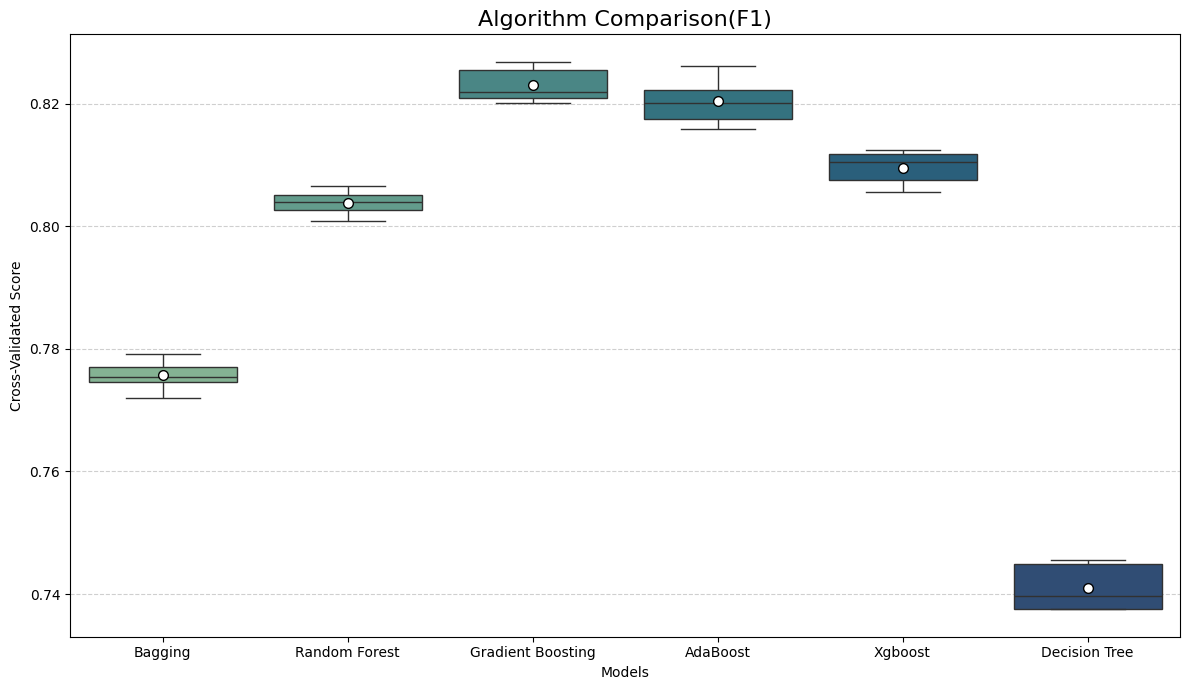

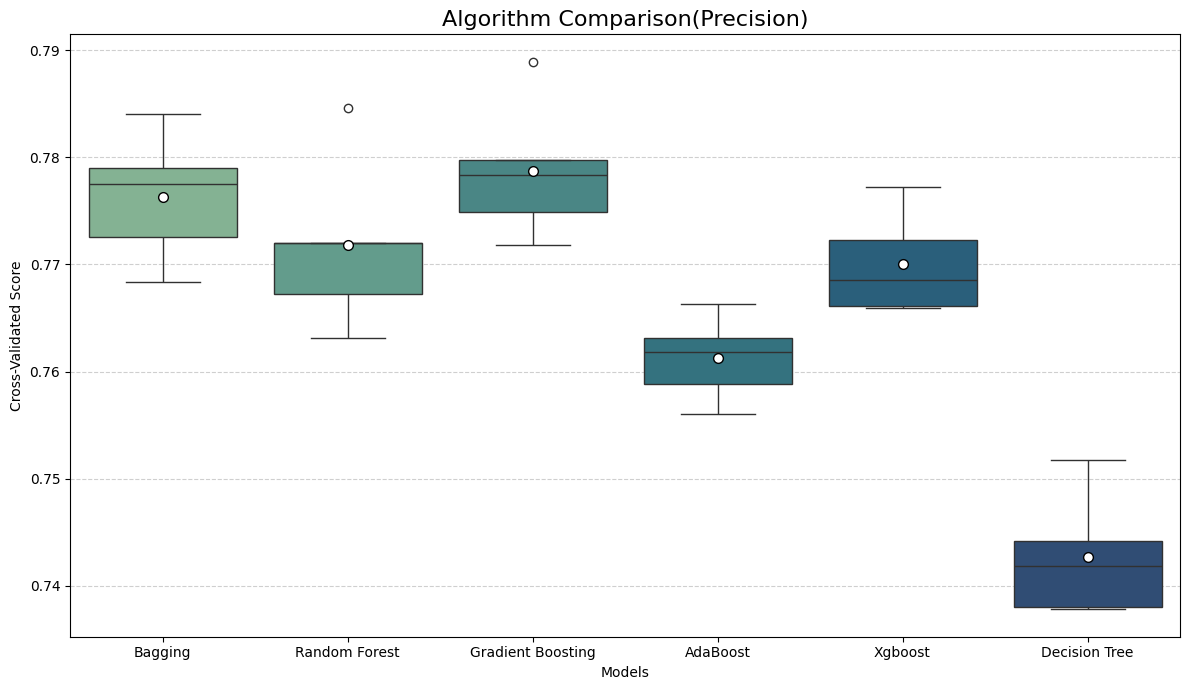

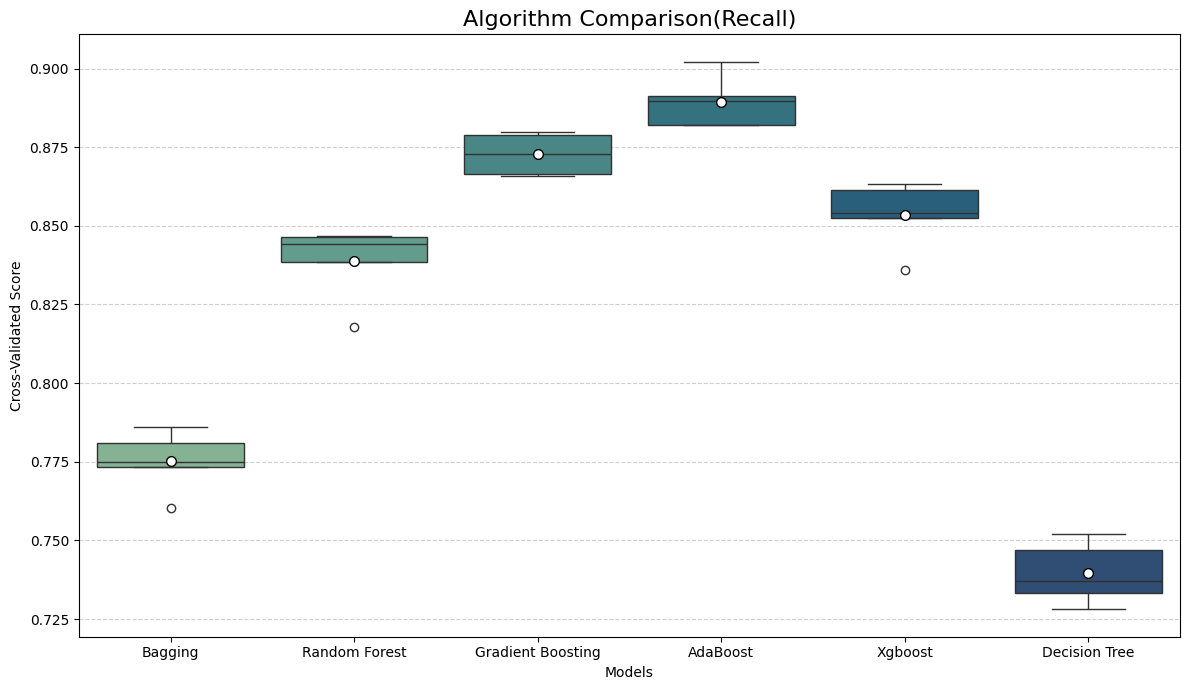

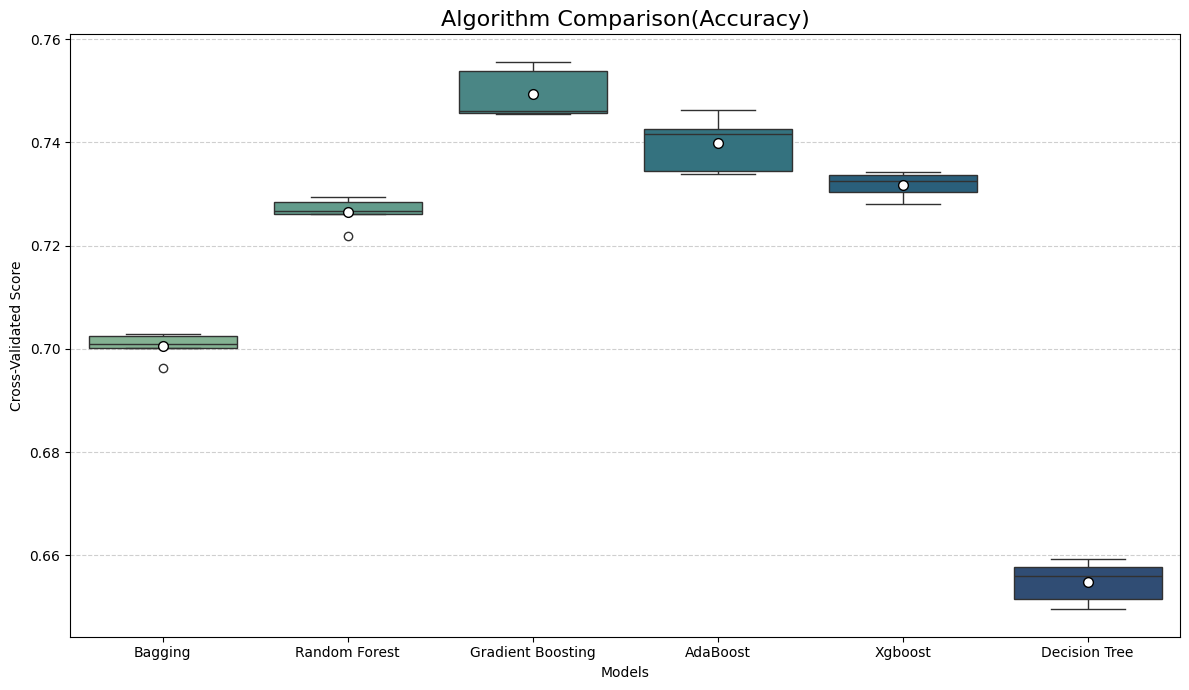

In [ ]:
# Combined plotting of CV results
metrics_to_plot = [("F1 Score", "Algorithm Comparison(F1)"),
                   ("Precision", "Algorithm Comparison(Precision)"),
                   ("Recall", "Algorithm Comparison(Recall)"),
                   ("Accuracy", "Algorithm Comparison(Accuracy)")]

for metric, plot_title in metrics_to_plot:
    model_names, score_arrays = cv_results_all[metric]
    cv_df = pd.DataFrame(dict(zip(model_names, score_arrays)))
    #cv_df.columns = names
    cv_df_melted = cv_df.melt(var_name="Model", value_name="Score")
    plt.figure(figsize=(12, 7))
    sns.boxplot(x="Model", y="Score", data=cv_df_melted, palette="crest", showmeans=True,
                meanprops={"marker":"o",
                           "markerfacecolor":"white",
                           "markeredgecolor":"black",
                           "markersize":"7"})
    plt.title(plot_title, fontsize=16)
    plt.ylabel("Cross-Validated Score")
    plt.xlabel("Models")
    plt.grid(axis="y", linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()

Top 3 models using original data
*   GBM
*   Adaboost
*   Xgboost

### Model Building with Oversampled data

In [ ]:
# Display class distribution before oversampling
counter_before = Counter(y_train)
print("Before OverSampling:")
for label, count in counter_before.items():
    print(f"  Label {label} Count: {count}")
print()

# Apply SMOTE for class balancing
smote = SMOTE(sampling_strategy=1.0, k_neighbors=5, random_state=1)
x_train_over, y_train_over = smote.fit_resample(x_train, y_train)

# Display class distribution after oversampling
counter_after = Counter(y_train_over)
print("After OverSampling:")
for label, count in counter_after.items():
    print(f"  Label {label} Count: {count}")
print()

print(f"Oversampled x_train_over shape: {x_train_over.shape}")
print(f"Oversampled y_train_over shape: {y_train_over.shape}\n")

Before OverSampling:
  Label 1 Count: 11913
  Label 0 Count: 5923

After OverSampling:
  Label 1 Count: 11913
  Label 0 Count: 11913

Oversampled x_train_over shape: (23826, 21)
Oversampled y_train_over shape: (23826,)



In [ ]:
# Define models with readable names in a list of tuples
models = [
    ("Bagging", BaggingClassifier(random_state=1)),
    ("Random Forest", RandomForestClassifier(random_state=1)),
    ("Gradient Boosting", GradientBoostingClassifier(random_state=1)),
    ("AdaBoost", AdaBoostClassifier(random_state=1)),
    ("Xgboost", XGBClassifier(random_state=1, eval_metric="logloss")),
    ("Decision Tree", DecisionTreeClassifier(random_state=1))
]

scoring_strategies = [
    ("F1 Score", scorer_f1, f1_score),
    ("Precision", scorer_precision, precision_score),
    ("Recall", scorer_recall, recall_score),
    ("Accuracy", scorer_accuracy, accuracy_score)
]

# Use the same StratifiedKFold split object for reproducibility
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

cv_results_all = {}
val_results_all = {}

for scorer_name, scorer, metric_func in scoring_strategies:
    print(f"\nCross-Validation performance on oversampled training dataset ({scorer_name}):\n")
    cv_results = []
    scoring_names = []
    for name, model in models:
        cv_scores = cross_val_score(
            estimator=model,
            X=x_train_over,
            y=y_train_over,
            scoring=scorer,
            cv=kfold,
            n_jobs=-1
        )
        cv_results.append(cv_scores)
        scoring_names.append(name)
        print(f"{name}: {cv_scores.mean():.4f} (std: {cv_scores.std():.4f})")
    cv_results_all[scorer_name] = (scoring_names.copy(), [arr.copy() for arr in cv_results])

    print(f"\nValidation Performance({scorer_name}):\n")
    model_val_scores = {}
    for name, model in models:
        model.fit(x_train_over, y_train_over)
        y_pred = model.predict(x_val)
        score_val = metric_func(y_val, y_pred)
        model_val_scores[name] = score_val
        print(f"{name}: {score_val:.4f}")
    val_results_all[scorer_name] = model_val_scores.copy()



Cross-Validation performance on oversampled training dataset (F1 Score):

Bagging: 0.7554 (std: 0.0071)
Random Forest: 0.7935 (std: 0.0044)
Gradient Boosting: 0.8077 (std: 0.0043)
AdaBoost: 0.8013 (std: 0.0026)
Xgboost: 0.7994 (std: 0.0033)
Decision Tree: 0.7236 (std: 0.0060)

Validation Performance(F1 Score):

Bagging: 0.7607
Random Forest: 0.7954
Gradient Boosting: 0.8125
AdaBoost: 0.8120
Xgboost: 0.8040
Decision Tree: 0.7388

Cross-Validation performance on oversampled training dataset (Precision):

Bagging: 0.7674 (std: 0.0039)
Random Forest: 0.7695 (std: 0.0046)
Gradient Boosting: 0.7620 (std: 0.0050)
AdaBoost: 0.7428 (std: 0.0045)
Xgboost: 0.7593 (std: 0.0024)
Decision Tree: 0.7285 (std: 0.0042)

Validation Performance(Precision):

Bagging: 0.7732
Random Forest: 0.7734
Gradient Boosting: 0.7758
AdaBoost: 0.7589
Xgboost: 0.7700
Decision Tree: 0.7532

Cross-Validation performance on oversampled training dataset (Recall):

Bagging: 0.7438 (std: 0.0118)
Random Forest: 0.8191 (std: 0

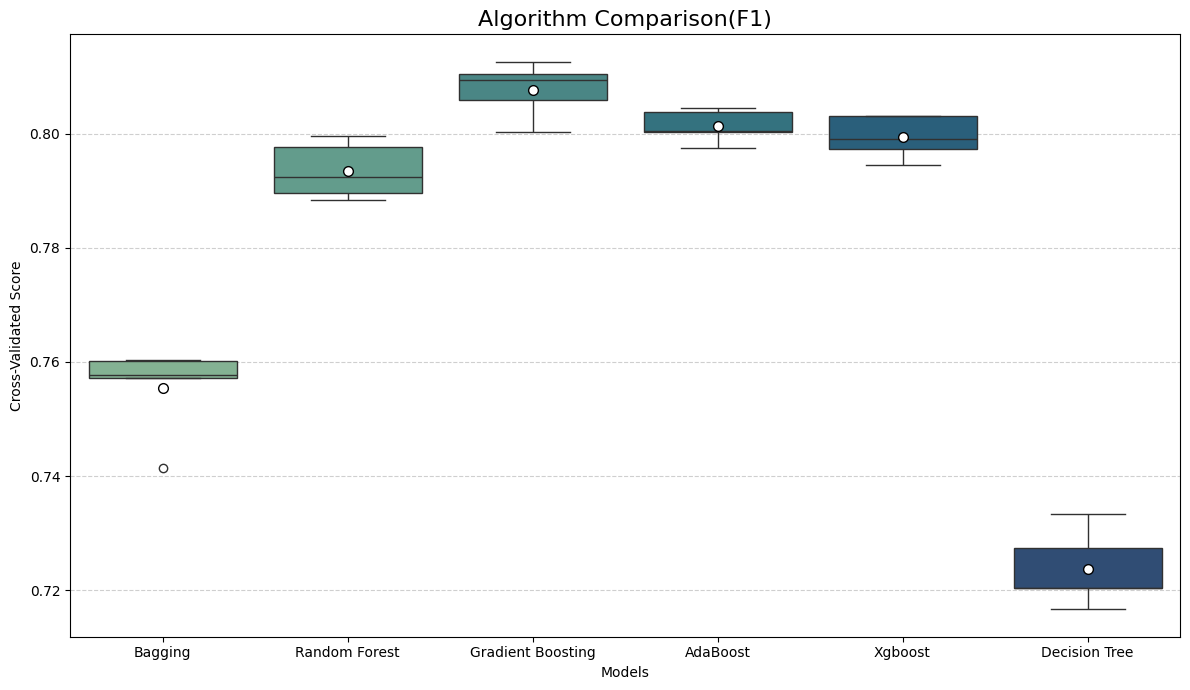

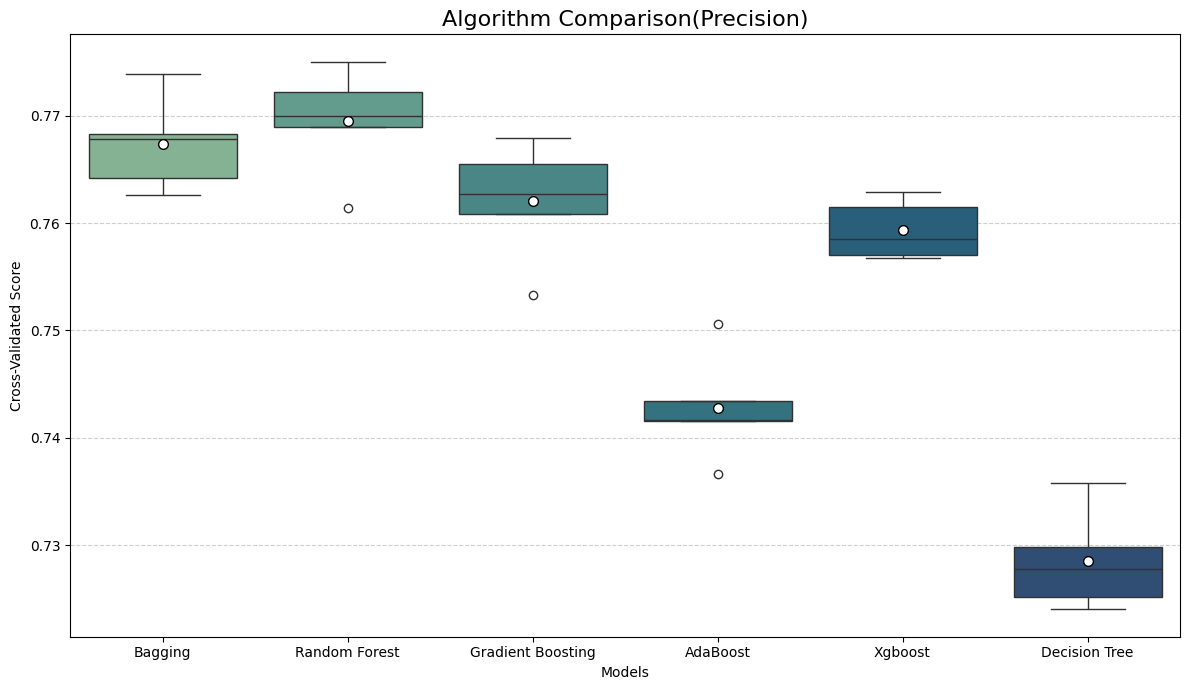

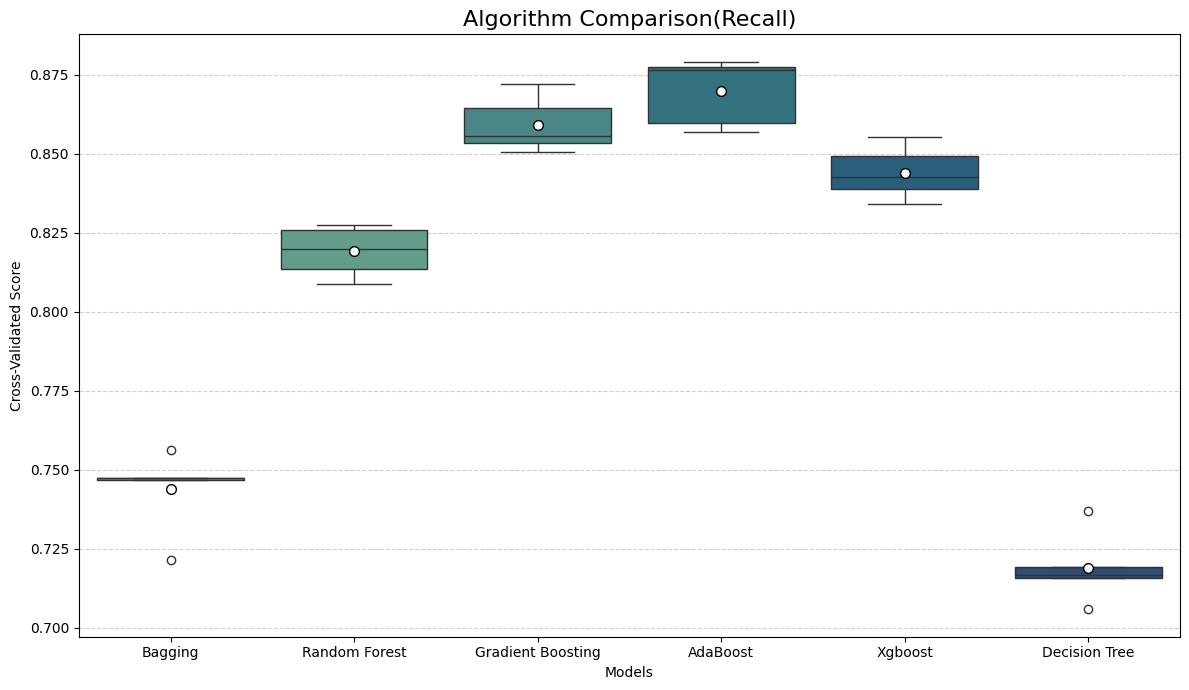

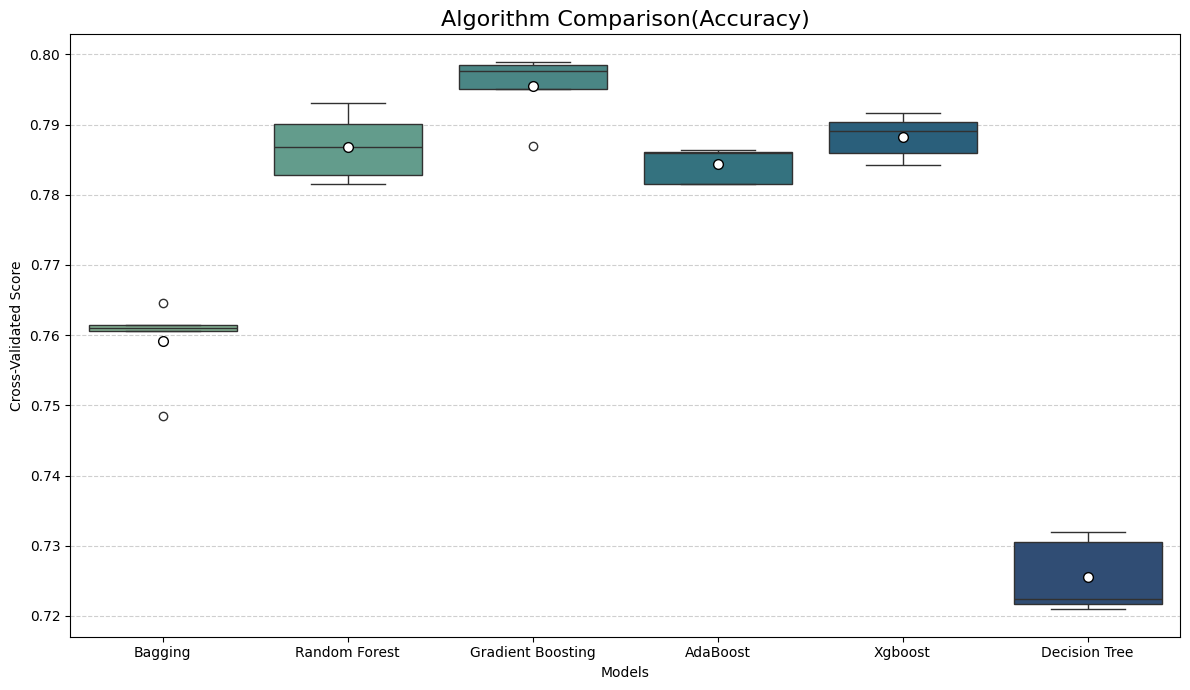

In [ ]:
# Combined plotting of CV results
metrics_to_plot = [("F1 Score", "Algorithm Comparison(F1)"),
                   ("Precision", "Algorithm Comparison(Precision)"),
                   ("Recall", "Algorithm Comparison(Recall)"),
                   ("Accuracy", "Algorithm Comparison(Accuracy)")]

for metric, plot_title in metrics_to_plot:
    model_names, score_arrays = cv_results_all[metric]
    cv_df = pd.DataFrame(dict(zip(model_names, score_arrays)))
    #cv_df.columns = names
    cv_df_melted = cv_df.melt(var_name="Model", value_name="Score")
    plt.figure(figsize=(12, 7))
    sns.boxplot(x="Model", y="Score", data=cv_df_melted, palette="crest", showmeans=True,
                meanprops={"marker":"o",
                           "markerfacecolor":"white",
                           "markeredgecolor":"black",
                           "markersize":"7"})
    plt.title(plot_title, fontsize=16)
    plt.ylabel("Cross-Validated Score")
    plt.xlabel("Models")
    plt.grid(axis="y", linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()

Top 3 models using oversampled data
* GBM
* Adaboost
* Xgboost

### Model Building with Undersampled data

In [ ]:
# Print label distributions before undersampling
counter_before = Counter(y_train)
print("Before UnderSampling:")
for label, count in counter_before.items():
    print(f"  Label {label} Count: {count}")
print()

# Apply random undersampling to balance the classes
under_sampler = RandomUnderSampler(random_state=1, sampling_strategy=1)
x_train_un, y_train_un = under_sampler.fit_resample(x_train, y_train)


counter_after = Counter(y_train_un)
print("After UnderSampling:")
for label, count in counter_after.items():
    print(f"  Label {label} Count: {count}")
print()

# Print new shapes for verification
print(f"Undersampled x_train_un shape:{x_train_un.shape}")
print(f"Undersampled y_train_un shape: {y_train_un.shape}\n")

Before UnderSampling:
  Label 1 Count: 11913
  Label 0 Count: 5923

After UnderSampling:
  Label 0 Count: 5923
  Label 1 Count: 5923

Undersampled x_train_un shape:(11846, 21)
Undersampled y_train_un shape: (11846,)



In [ ]:
# Define models with readable names in a list of tuples
models = [
    ("Bagging", BaggingClassifier(random_state=1)),
    ("Random Forest", RandomForestClassifier(random_state=1)),
    ("Gradient Boosting", GradientBoostingClassifier(random_state=1)),
    ("AdaBoost", AdaBoostClassifier(random_state=1)),
    ("Xgboost", XGBClassifier(random_state=1, eval_metric="logloss")),
    ("Decision Tree", DecisionTreeClassifier(random_state=1))
]

scoring_strategies = [
    ("F1 Score", scorer_f1, f1_score),
    ("Precision", scorer_precision, precision_score),
    ("Recall", scorer_recall, recall_score),
    ("Accuracy", scorer_accuracy, accuracy_score)
]

# Use the same StratifiedKFold split object for reproducibility
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

cv_results_all = {}
val_results_all = {}

for scorer_name, scorer, metric_func in scoring_strategies:
    print(f"\nCross-Validation performance on undersampled training dataset ({scorer_name}):\n")
    cv_results = []
    scoring_names = []
    for name, model in models:
        cv_scores = cross_val_score(
            estimator=model,
            X=x_train_un,
            y=y_train_un,
            scoring=scorer,
            cv=kfold,
            n_jobs=-1
        )
        cv_results.append(cv_scores)
        scoring_names.append(name)
        print(f"{name}: {cv_scores.mean():.4f} (std: {cv_scores.std():.4f})")
    cv_results_all[scorer_name] = (scoring_names.copy(), [arr.copy() for arr in cv_results])

    print(f"\nValidation Performance({scorer_name}):\n")
    model_val_scores = {}
    for name, model in models:
        model.fit(x_train_un, y_train_un)
        y_pred = model.predict(x_val)
        score_val = metric_func(y_val, y_pred)
        model_val_scores[name] = score_val
        print(f"{name}: {score_val:.4f}")
    val_results_all[scorer_name] = model_val_scores.copy()



Cross-Validation performance on undersampled training dataset (F1 Score):

Bagging: 0.6411 (std: 0.0093)
Random Forest: 0.6875 (std: 0.0064)
Gradient Boosting: 0.7131 (std: 0.0082)
AdaBoost: 0.6949 (std: 0.0090)
Xgboost: 0.6945 (std: 0.0092)
Decision Tree: 0.6170 (std: 0.0066)

Validation Performance(F1 Score):

Bagging: 0.6917
Random Forest: 0.7341
Gradient Boosting: 0.7609
AdaBoost: 0.7604
Xgboost: 0.7424
Decision Tree: 0.6839

Cross-Validation performance on undersampled training dataset (Precision):

Bagging: 0.6833 (std: 0.0119)
Random Forest: 0.6920 (std: 0.0075)
Gradient Boosting: 0.7077 (std: 0.0039)
AdaBoost: 0.6812 (std: 0.0066)
Xgboost: 0.6925 (std: 0.0046)
Decision Tree: 0.6163 (std: 0.0063)

Validation Performance(Precision):

Bagging: 0.8064
Random Forest: 0.8115
Gradient Boosting: 0.8216
AdaBoost: 0.8097
Xgboost: 0.8099
Decision Tree: 0.7600

Cross-Validation performance on undersampled training dataset (Recall):

Bagging: 0.6041 (std: 0.0124)
Random Forest: 0.6831 (std

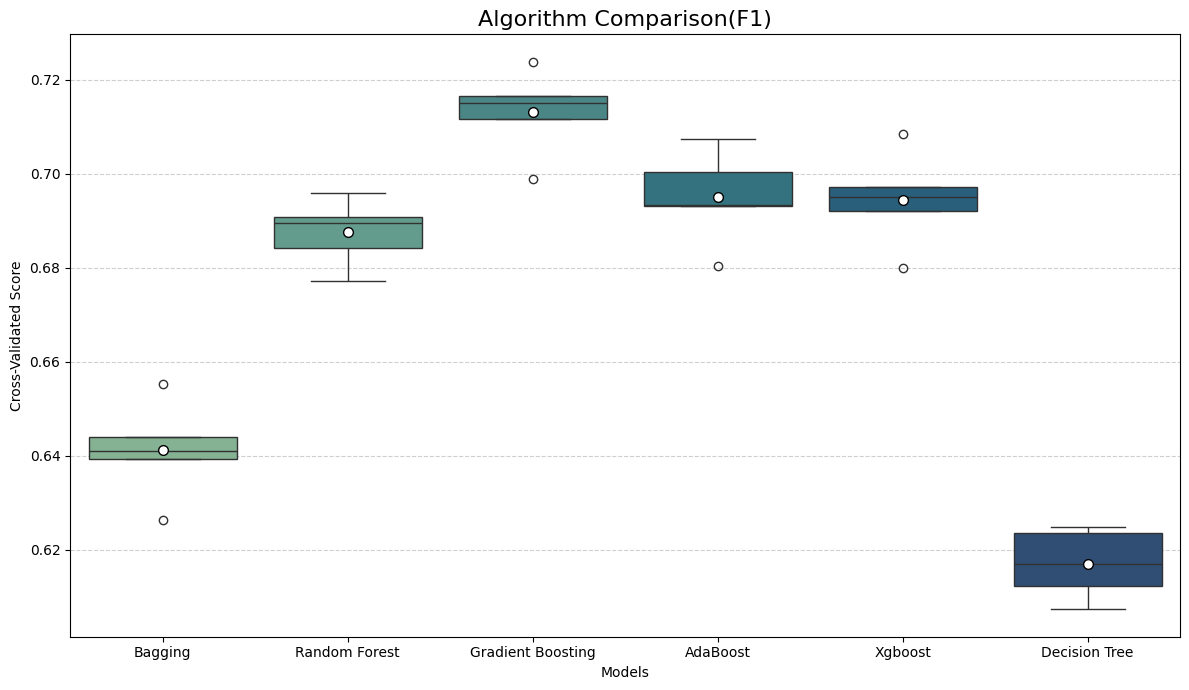

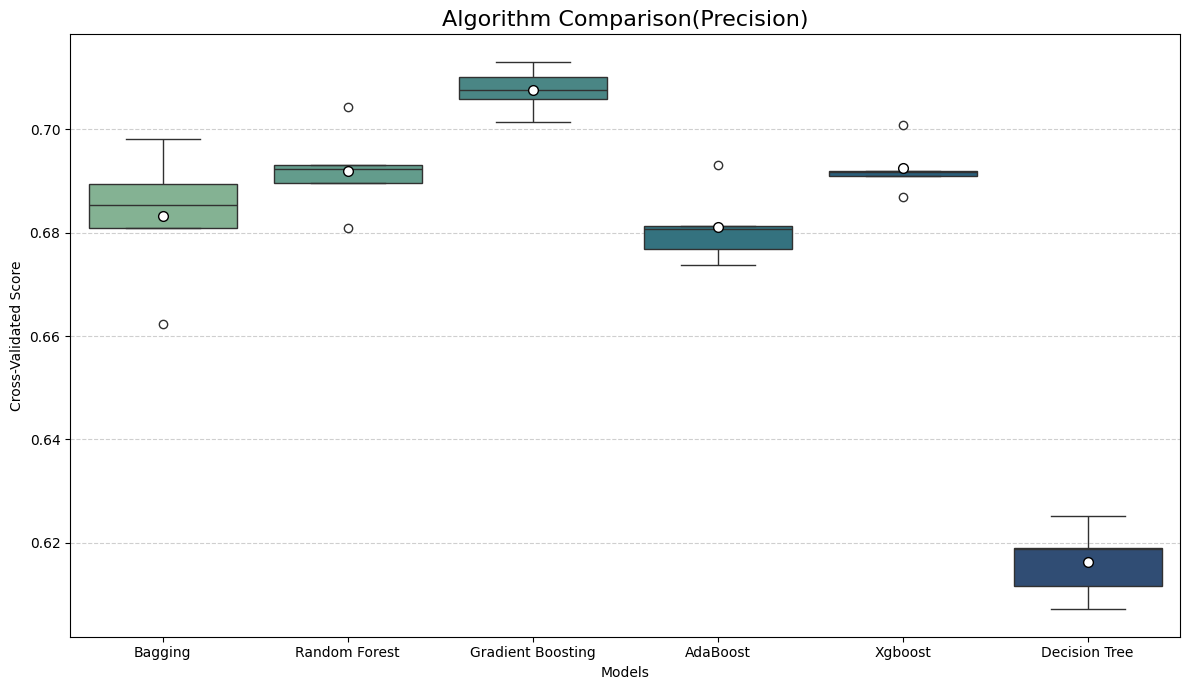

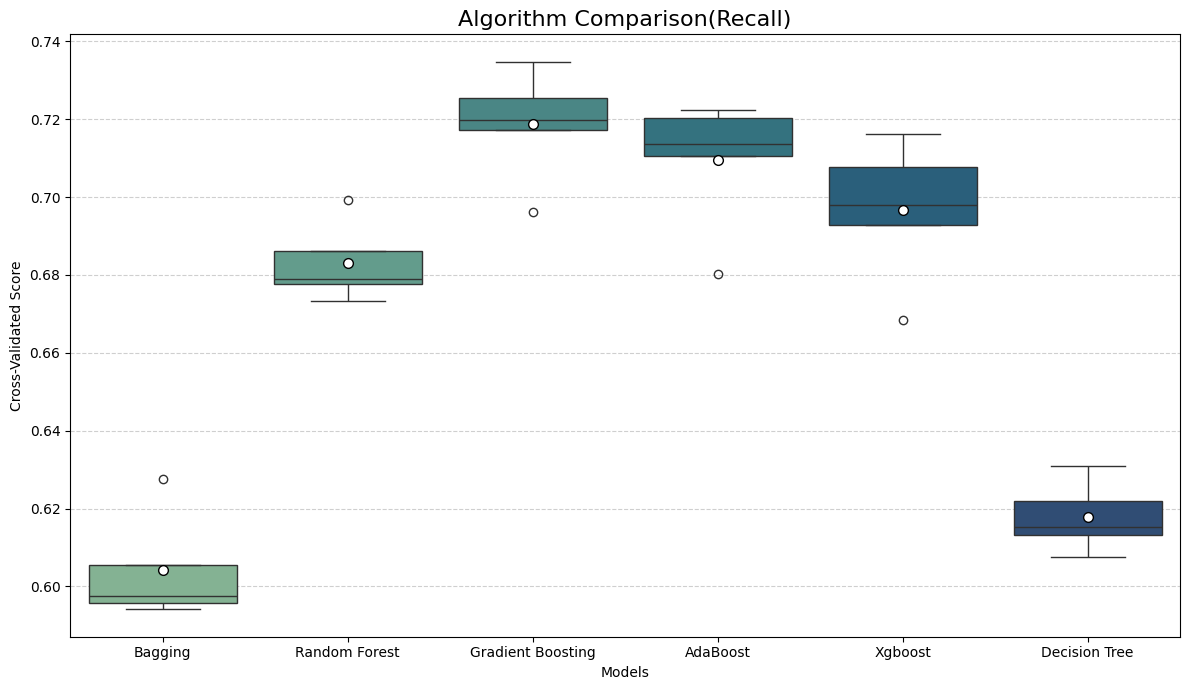

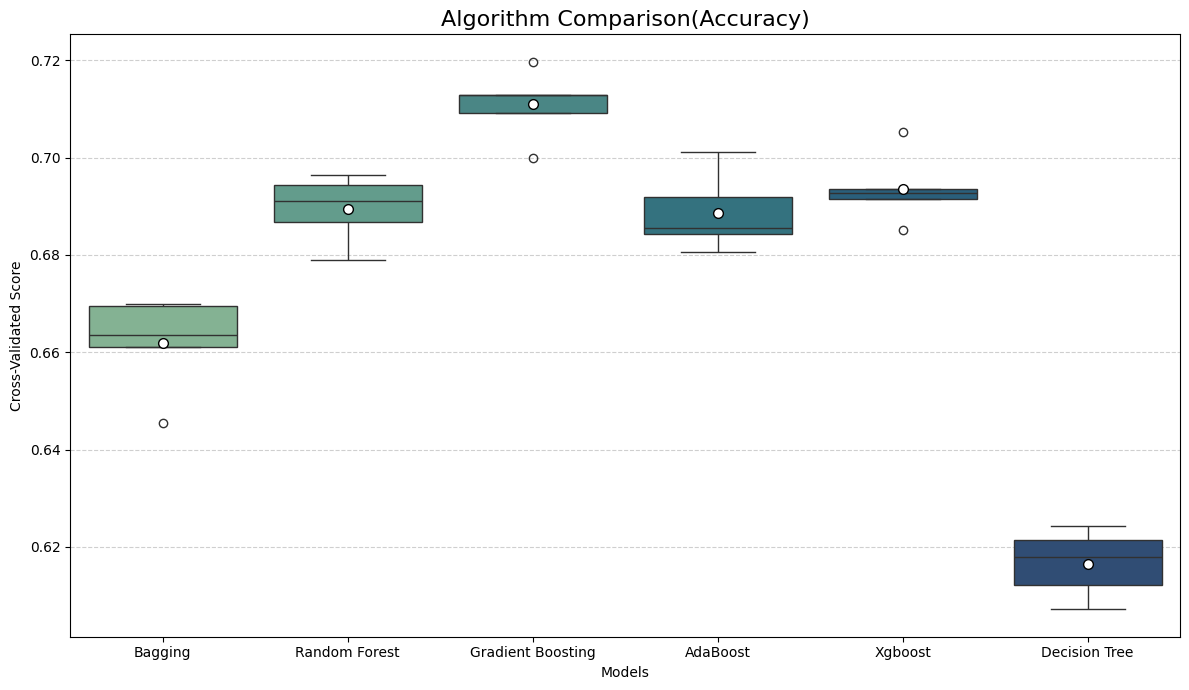

In [ ]:
# Combined plotting of CV results
metrics_to_plot = [("F1 Score", "Algorithm Comparison(F1)"),
                   ("Precision", "Algorithm Comparison(Precision)"),
                   ("Recall", "Algorithm Comparison(Recall)"),
                   ("Accuracy", "Algorithm Comparison(Accuracy)")]

for metric, plot_title in metrics_to_plot:
    model_names, score_arrays = cv_results_all[metric]
    cv_df = pd.DataFrame(dict(zip(model_names, score_arrays)))
    #cv_df.columns = names
    cv_df_melted = cv_df.melt(var_name="Model", value_name="Score")
    plt.figure(figsize=(12, 7))
    sns.boxplot(x="Model", y="Score", data=cv_df_melted, palette="crest", showmeans=True,
                meanprops={"marker":"o",
                           "markerfacecolor":"white",
                           "markeredgecolor":"black",
                           "markersize":"7"})
    plt.title(plot_title, fontsize=16)
    plt.ylabel("Cross-Validated Score")
    plt.xlabel("Models")
    plt.grid(axis="y", linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()

Top 3 models using undersampled data
*   GBM
*   Adaboost
*   Xgboost


## Hyperparameter Tuning

### Hyperparameter Tuning AdaBoost using Oversampled data

**Best practices for hyperparameter tuning in AdaBoost:**

`n_estimators`:

- Start with a specific number (50 is used in general) and increase in steps: 50, 75, 85, 100

- Use fewer estimators (e.g., 50 to 100) if using complex base learners (like deeper decision trees)

- Use more estimators (e.g., 100 to 150) when learning rate is low (e.g., 0.1 or lower)

- Avoid very high values unless performance keeps improving on validation

`learning_rate`:

- Common values to try: 1.0, 0.5, 0.1, 0.01

- Use 1.0 for faster training, suitable for fewer estimators

- Use 0.1 or 0.01 when using more estimators to improve generalization

- Avoid very small values (< 0.01) unless you plan to use many estimators (e.g., >500) and have sufficient data


---

In [ ]:
%%time

# defining model
model = AdaBoostClassifier(random_state=1)

# Parameter grid to pass in RandomSearchCV
param_grid = {
    "n_estimators": [50, 75, 100, 125],
    "learning_rate": [1.0, 0.5, 0.2, 0.1],
    "estimator": [
        DecisionTreeClassifier(max_depth=1, min_samples_split=2, random_state=1),
        DecisionTreeClassifier(max_depth=2, min_samples_split=4, random_state=1),
        DecisionTreeClassifier(max_depth=3, min_samples_split=6, random_state=1),
    ]
}
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)


#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grid,
    n_iter=30,
    n_jobs=-1,
    scoring=scorer_f1,
    cv=cv_strategy,
    random_state=1,
    verbose=2,
    return_train_score=True
)
randomized_cv.fit(x_train_over, y_train_over)
#randomized_cv.fit(x_train, y_train)



Fitting 5 folds for each of 30 candidates, totalling 150 fits
CPU times: user 7.81 s, sys: 447 ms, total: 8.26 s
Wall time: 6min 4s


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=1, shuffle=True),
                   estimator=AdaBoostClassifier(random_state=1), n_iter=30,
                   n_jobs=-1,
                   param_distributions={'estimator': [DecisionTreeClassifier(max_depth=1,
                                                                             random_state=1),
                                                      DecisionTreeClassifier(max_depth=2,
                                                                             min_samples_split=4,
                                                                             random_state=1),
                                                      DecisionTreeClassifier(max_depth=3,
                                                                             min_samples_split=6,
                                                                             random_state=1)],
                                        'learning_rate': [1.0, 0.5, 0.2, 0.1],
                                        'n_estimators': [50, 75, 100, 125]},
                   random_state=1, return_train_score=True,
                   scoring=make_scorer(f1_score, response_method='predict'),
                   verbose=2)

Best parameters are {'n_estimators': 100, 'learning_rate': 0.5, 'estimator': DecisionTreeClassifier(max_depth=3, min_samples_split=6, random_state=1)} with CV score=0.8037559763906834:


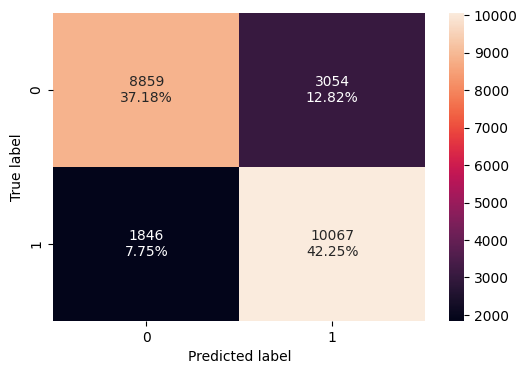

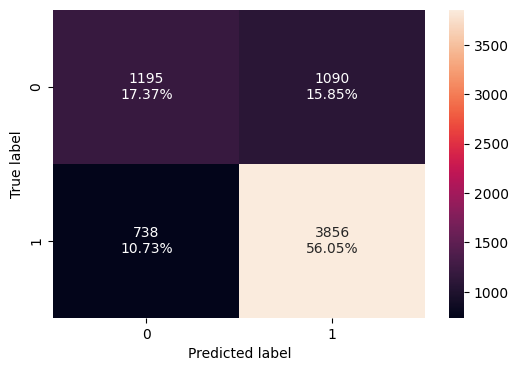

In [ ]:
print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))
tuned_ada = randomized_cv.best_estimator_

#Fitting parameters in RandomizedSearchCV
tuned_ada.fit(x_train_over,y_train_over) ## Complete the code to fit the model on oversampled data

confusion_matrix_sklearn(tuned_ada,x_train_over, y_train_over)
confusion_matrix_sklearn(tuned_ada, x_val,y_val)




In [ ]:
tuned_ada_train_perf = model_performance_classification_sklearn(tuned_ada, x_train_over, y_train_over)
tuned_ada_test_perf = model_performance_classification_sklearn(tuned_ada, x_test, y_test)
tuned_ada_val_perf = model_performance_classification_sklearn(tuned_ada, x_val, y_val)

pd.concat([
    tuned_ada_train_perf,
    tuned_ada_test_perf,
    tuned_ada_val_perf],
keys=["Training Performance", "Testing Performance","Validation Performance"]).reset_index(level=1, drop=True)

,Accuracy,Recall,Precision,F1
Training Performance,0.794342,0.845043,0.767243,0.804266
Testing Performance,0.750327,0.864971,0.783688,0.822326
Validation Performance,0.734264,0.839356,0.779620,0.808386


### Hyperparameter Tuning Gradient Boosting using Oversampled data

**Best practices for hyperparameter tuning in Gradient Boosting:**

`n_estimators`:

* Start with 100 (default) and increase: 100, 200, 300, 500
* Typically, higher values lead to better performance, but they also increase training time
* Use 200–500 for larger datasets or complex problems
* Monitor validation performance to avoid overfitting, as too many estimators can degrade generalization


`learning_rate`:

* Common values to try: 0.1, 0.05, 0.01, 0.005
* Use lower values (e.g., 0.01 or 0.005) if you are using many estimators (e.g., > 200)
* Higher learning rates (e.g., 0.1) can be used with fewer estimators for faster convergence
* Always balance the learning rate with `n_estimators` to prevent overfitting or underfitting


`subsample`:

* Common values: 0.7, 0.8, 0.9, 1.0
* Use a value between `0.7` and `0.9` for improved generalization by introducing randomness
* `1.0` uses the full dataset for each boosting round, potentially leading to overfitting
* Reducing `subsample` can help reduce overfitting, especially in smaller datasets


`max_features`:

* Common values: `"sqrt"`, `"log2"`, or float (e.g., `0.3`, `0.5`)
* `"sqrt"` (default) works well for classification tasks
* Lower values (e.g., `0.3`) help reduce overfitting by limiting the number of features considered at each split

---

In [ ]:
%%time

# defining model
model = GradientBoostingClassifier(random_state=1)

## Complete the code to define the hyper parameters.
param_grid={
    "n_estimators": [100, 150, 200],
    "learning_rate": [0.1, 0.05],
    "subsample": [0.7, 0.8, 0.9],
    "max_features": ["sqrt", "log2"]
}


cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grid,
    n_iter=50,
    n_jobs=-1,
    scoring=scorer_f1,
    cv=cv_strategy,
    verbose=2,
)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(x_train_over, y_train_over)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
CPU times: user 4.57 s, sys: 351 ms, total: 4.92 s
Wall time: 4min 17s


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=1, shuffle=True),
                   estimator=GradientBoostingClassifier(random_state=1),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'learning_rate': [0.1, 0.05],
                                        'max_features': ['sqrt', 'log2'],
                                        'n_estimators': [100, 150, 200],
                                        'subsample': [0.7, 0.8, 0.9]},
                   scoring=make_scorer(f1_score, response_method='predict'),
                   verbose=2)

Best parameters are {'subsample': 0.7, 'n_estimators': 200, 'max_features': 'sqrt', 'learning_rate': 0.1} with CV score=0.8063664114903126:


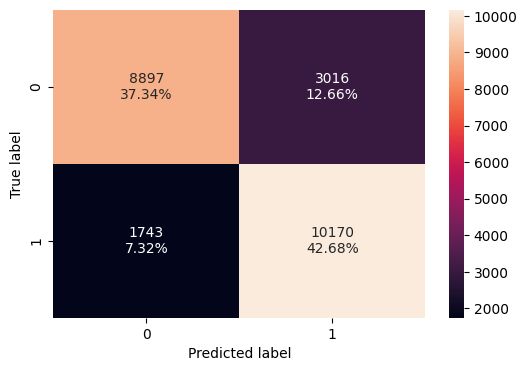

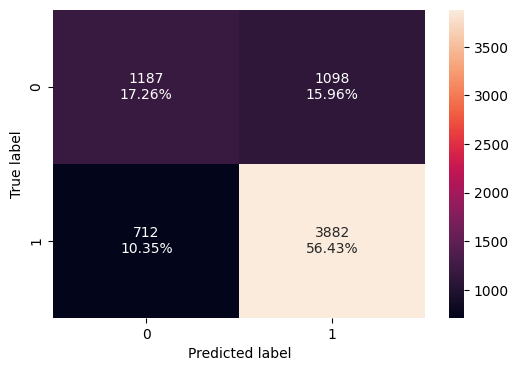

In [ ]:
print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))
tuned_gbm = randomized_cv.best_estimator_
#Fitting parameters in RandomizedSearchCV
#bag_tnd.fit(x_train_un,y_train_un) ## Complete the code to fit the model on undersampled data

confusion_matrix_sklearn(tuned_gbm, x_train_over,y_train_over)
confusion_matrix_sklearn(tuned_gbm, x_val,y_val)

In [ ]:
tuned_gbm_train_perf = model_performance_classification_sklearn(tuned_gbm, x_train_over, y_train_over)
tuned_gbm_test_perf = model_performance_classification_sklearn(tuned_gbm, x_test, y_test)
tuned_gbm_val_perf = model_performance_classification_sklearn(tuned_gbm, x_val, y_val)
pd.concat([
    tuned_gbm_train_perf,
    tuned_gbm_test_perf,
    tuned_gbm_val_perf,
], keys=["Training Performance", "Testing Performance", "Validation Performance"]).reset_index(level=1, drop=True)

,Accuracy,Recall,Precision,F1
Training Performance,0.80026,0.853689,0.771273,0.810391
Testing Performance,0.74902,0.859100,0.785331,0.820561
Validation Performance,0.73688,0.845015,0.779518,0.810946


### Hyperparameter Tuning XGBoost using Oversampled data

**Best practices for hyperparameter tuning in XGBoost:**

`n_estimators`:

* Start with 50 and increase in steps: 50,75,100,125.
* Use more estimators (e.g., 150-250) when using lower learning rates
* Monitor validation performance
* High values improve learning but increase training time

`subsample`:

* Common values: 0.5, 0.7, 0.8, 1.0
* Use `0.7–0.9` to introduce randomness and reduce overfitting
* `1.0` uses the full dataset in each boosting round; may overfit on small datasets
* Values < 0.5 are rarely useful unless dataset is very large

`gamma`:

* Try values: 0 (default), 1, 3, 5, 8
* Controls minimum loss reduction needed for a split
* Higher values make the algorithm more conservative (i.e., fewer splits)
* Use values > 0 to regularize and reduce overfitting, especially on noisy data


`colsample_bytree`:

* Try values: 0.3, 0.5, 0.7, 1.0
* Fraction of features sampled per tree
* Lower values (e.g., 0.3 or 0.5) increase randomness and improve generalization
* Use `1.0` when you want all features considered for every tree


`colsample_bylevel`:

* Try values: 0.3, 0.5, 0.7, 1.0
* Fraction of features sampled at each tree level (i.e., per split depth)
* Lower values help in regularization and reducing overfitting
* Often used in combination with `colsample_bytree` for fine control over feature sampling

---

In [ ]:
%%time

# Define the XGBoost model with a fixed random state and evaluation metric
model = XGBClassifier(random_state=1, eval_metric='logloss')

# Define a well-structured hyperparameter grid following best practices
param_grid = {
    'n_estimators': [50, 75, 100, 125],                 # Number of boosting rounds
    'subsample': [0.5, 0.7, 0.8],                                # Subsample ratios for training instances
    'gamma': [0, 1, 3, 5, 8],                                    # Minimum loss reduction for a split
    'colsample_bytree': [0.3, 0.5, 0.7, 1.0],                    # Fraction of features per tree
    'colsample_bylevel': [0.3, 0.5, 0.7, 1.0]                    # Fraction of features per level
}



# 5-fold Stratified Cross Validation
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

# Setup RandomizedSearchCV with reasonable settings for reproducibility and speed
randomized_cv = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grid,
    n_iter=50,
    n_jobs=-1,             # Use all processors for efficiency
    scoring=scorer_f1,
    cv=cv_strategy,
    verbose=1              # Show progress for debugging/tuning
)

# Fit the model using oversampled training data
randomized_cv.fit(x_train_over, y_train_over)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
CPU times: user 1.78 s, sys: 166 ms, total: 1.95 s
Wall time: 50.6 s


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=1, shuffle=True),
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric='logloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,...
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'colsample_bylevel': [0.3, 0.5, 0.7,
                                                              1.0],
                                        'colsample_bytree': [0.3, 0.5, 0.7,
                                                             1.0],
                                        'gamma': [0, 1, 3, 5, 8],
                                        'n_estimators': [50, 75, 100, 125],
                                        'subsample': [0.5, 0.7, 0.8]},
                   scoring=make_scorer(f1_score, response_method='predict'),
                   verbose=1)

Best parameters are {'subsample': 0.8, 'n_estimators': 125, 'gamma': 5, 'colsample_bytree': 0.7, 'colsample_bylevel': 1.0} with CV score=0.8074809308651375:


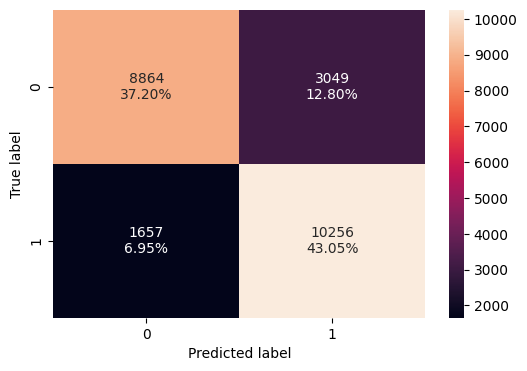

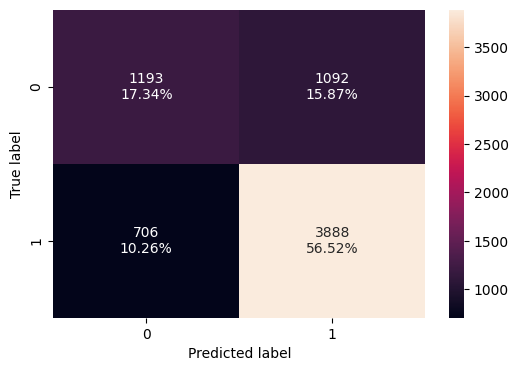

In [ ]:
print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))
tuned_xgb = randomized_cv.best_estimator_

confusion_matrix_sklearn(tuned_xgb, x_train_over,y_train_over)
confusion_matrix_sklearn(tuned_xgb, x_val,y_val)

In [ ]:
tuned_xgb_train_perf = model_performance_classification_sklearn(tuned_xgb, x_train_over, y_train_over)
tuned_xgb_test_perf = model_performance_classification_sklearn(tuned_xgb, x_test, y_test)
tuned_xgb_val_perf = model_performance_classification_sklearn(tuned_xgb, x_val, y_val)
pd.concat([
    tuned_xgb_train_perf,
    tuned_xgb_test_perf,
    tuned_xgb_val_perf,
], keys=["Training Performance", "Testing Performance", "Validation Performance"]).reset_index(level=1, drop=True)

,Accuracy,Recall,Precision,F1
Training Performance,0.757569,0.860908,0.793624,0.825898
Testing Performance,0.752941,0.863014,0.787500,0.823529
Validation Performance,0.738625,0.846321,0.780723,0.812200


### Hyperparameter Tuning in Bagging Boosting

In [ ]:
%%time


#base_estimator = DecisionTreeClassifier(max_depth=3, random_state=1)
model = BaggingClassifier(DecisionTreeClassifier(max_depth=3, random_state=1), random_state=1)

# Parameter grid to pass in RandomSearchCV
param_grid = {
    "n_estimators": [25, 50, 75, 100],
    "max_features": [0.4, 0.6, 0.8],
    "max_samples": [0.4, 0.6, 0.8],
    "bootstrap": [True, False],
    "bootstrap_features": [False, True]
}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

#Calling RandomizedSearchCV
bag_rd = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grid,
    n_iter=50,
    n_jobs=-1,
    scoring=scorer_f1,
    cv=cv_strategy,
    verbose=2
)

bag_rd.fit(x_train_un,y_train_un)
#bag_rd.fit(x_train,y_train)



Fitting 5 folds for each of 50 candidates, totalling 250 fits
CPU times: user 1.5 s, sys: 202 ms, total: 1.7 s
Wall time: 2min 7s


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=1, shuffle=True),
                   estimator=BaggingClassifier(estimator=DecisionTreeClassifier(max_depth=3,
                                                                                random_state=1),
                                               random_state=1),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'bootstrap': [True, False],
                                        'bootstrap_features': [False, True],
                                        'max_features': [0.4, 0.6, 0.8],
                                        'max_samples': [0.4, 0.6, 0.8],
                                        'n_estimators': [25, 50, 75, 100]},
                   scoring=make_scorer(f1_score, response_method='predict'),
                   verbose=2)

Best parameters are {'n_estimators': 25, 'max_samples': 0.4, 'max_features': 0.4, 'bootstrap_features': True, 'bootstrap': True} with CV score=0.7242719383249654:


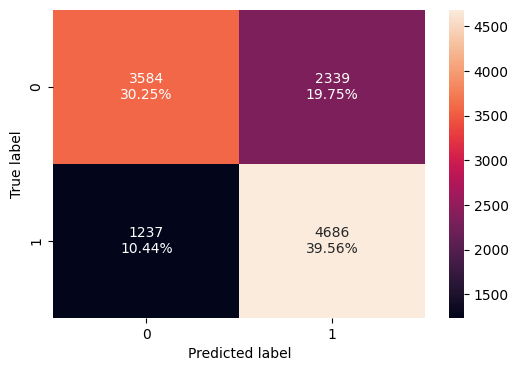

In [ ]:
print("Best parameters are {} with CV score={}:" .format(bag_rd.best_params_,bag_rd.best_score_))
bag_tnd = bag_rd.best_estimator_
#Fitting parameters in RandomizedSearchCV
#bag_tnd.fit(x_train_un,y_train_un) ## Complete the code to fit the model on undersampled data

confusion_matrix_sklearn(bag_tnd, x_train_un,y_train_un)

In [ ]:
tuned_bag_train_perf = model_performance_classification_sklearn(bag_tnd, x_train_un, y_train_un)
tuned_bag_test_perf = model_performance_classification_sklearn(bag_tnd, x_test, y_test)
tuned_bag_val_perf = model_performance_classification_sklearn(bag_tnd, x_val, y_val)
pd.concat([
    tuned_bag_train_perf,
    tuned_bag_test_perf,
    tuned_bag_val_perf,
], keys=["Training Performance", "Testing Performance", "Validation Performance"]).reset_index(level=1, drop=True)



,Accuracy,Recall,Precision,F1
Training Performance,0.698126,0.791153,0.667046,0.723818
Testing Performance,0.747712,0.821918,0.804598,0.813166
Validation Performance,0.725978,0.789943,0.797758,0.793831


## Model Performance Summary and Final Model Selection

In [ ]:
# Dynamically build lists for dataframes and column names to easily include/exclude models
train_perfs = [
    ("AdaBoost tuned with oversampled data", tuned_ada_train_perf.T),
    ("Gradient Boosting tuned with oversampled data", tuned_gbm_train_perf.T),
    ("XGBoost tuned with oversampled data", tuned_xgb_train_perf.T),
    ("Bagging tuned with undersampled data", tuned_bag_train_perf.T),
]

# Extract dataframes and names
train_perf_dfs = [item[1] for item in train_perfs if not str(item[1]).startswith("#")]
train_perf_names = [item[0] for item in train_perfs if not str(item[0]).startswith("#")]

models_train_comp_df = pd.concat(train_perf_dfs, axis=1)
models_train_comp_df.columns = train_perf_names

print("Training performance comparison:")
display(models_train_comp_df)


Training performance comparison:


,AdaBoost tuned with oversampled data,Gradient Boosting tuned with oversampled data,XGBoost tuned with oversampled data,Bagging tuned with undersampled data
Accuracy,0.794342,0.800260,0.757569,0.698126
Recall,0.845043,0.853689,0.860908,0.791153
Precision,0.767243,0.771273,0.793624,0.667046
F1,0.804266,0.810391,0.825898,0.723818


In [ ]:
# Dynamically build lists for dataframes and column names to easily include/exclude models
train_vals = [
    ("AdaBoost tuned with oversampled data", tuned_ada_val_perf.T),
    ("Gradient Boosting tuned with oversampled data", tuned_gbm_val_perf.T),
    ("XGBoost tuned with oversampled data", tuned_xgb_val_perf.T),
    ("Bagging tuned with undersampled data", tuned_bag_val_perf.T),
]

# Extract dataframes and names
train_val_dfs = [item[1] for item in train_vals if not str(item[1]).startswith("#")]
train_val_names = [item[0] for item in train_vals if not str(item[0]).startswith("#")]

models_val_comp_df = pd.concat(train_val_dfs, axis=1)
models_val_comp_df.columns = train_val_names

print("Validation performance comparison:")
display(models_val_comp_df)

Validation performance comparison:


,AdaBoost tuned with oversampled data,Gradient Boosting tuned with oversampled data,XGBoost tuned with oversampled data,Bagging tuned with undersampled data
Accuracy,0.734264,0.736880,0.738625,0.725978
Recall,0.839356,0.845015,0.846321,0.789943
Precision,0.779620,0.779518,0.780723,0.797758
F1,0.808386,0.810946,0.812200,0.793831


In [ ]:
final_model = tuned_xgb
test = model_performance_classification_sklearn(final_model, x_test, y_test)
test

,Accuracy,Recall,Precision,F1
0,0.752941,0.863014,0.7875,0.823529


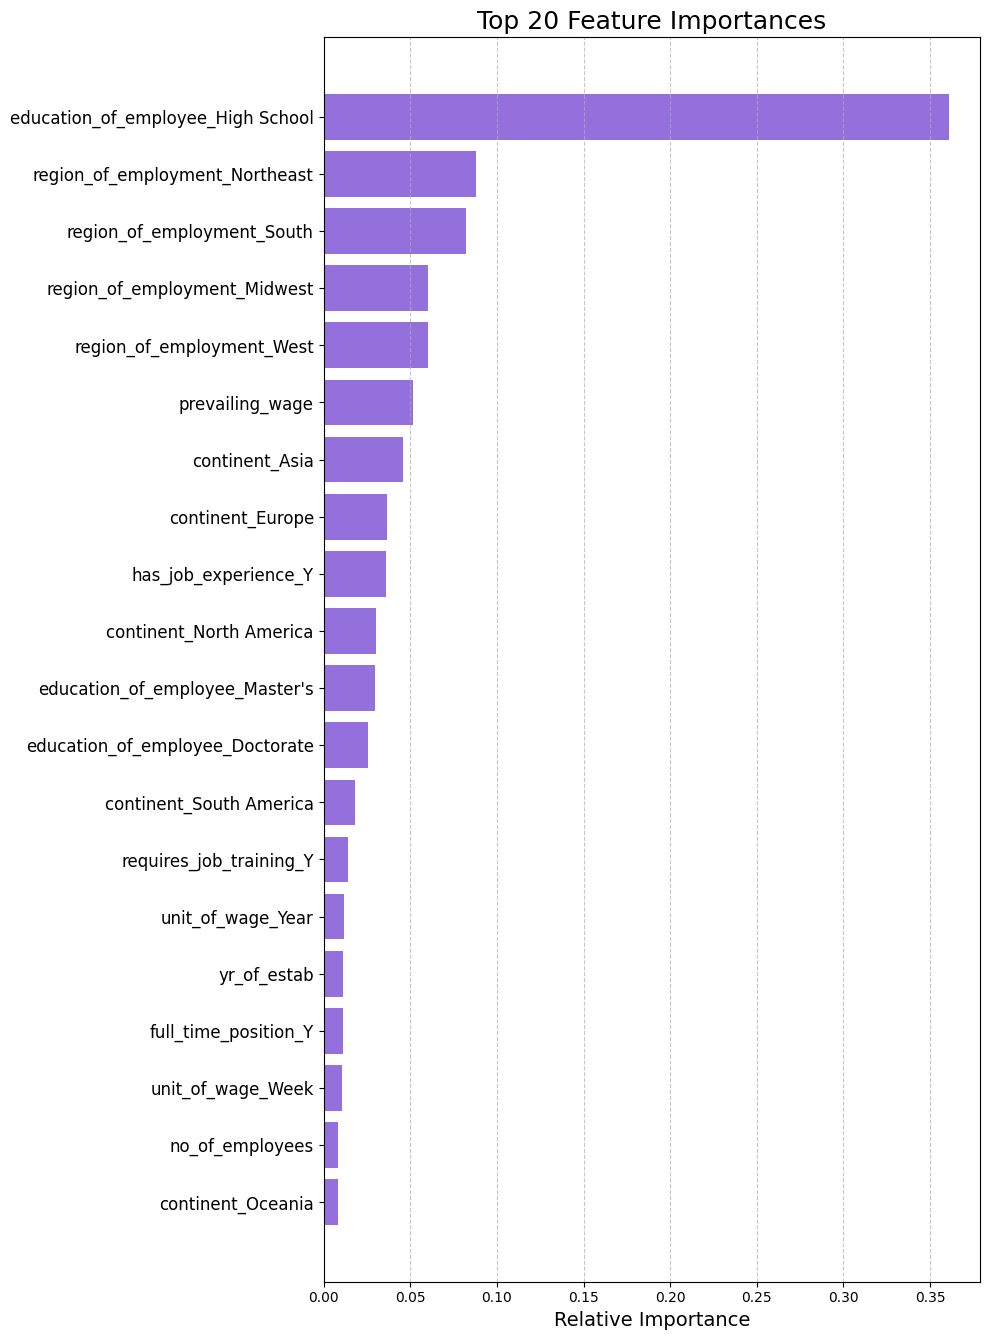

In [ ]:
importances = final_model.feature_importances_
feature_names = x_train.columns
# Sort features by importance (descending)
sorted_indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, min(0.5 * len(feature_names) + 3, 15)))
plt.title("Top 20 Feature Importances", fontsize=18)

top_n = 20  # Show top 20 features for readability
top_indices = sorted_indices[:top_n]

plt.barh(
    range(len(top_indices)),
    importances[top_indices][::-1],
    color="mediumpurple",
    align="center"
)
plt.yticks(
    range(len(top_indices)),
    [feature_names[i] for i in top_indices][::-1],
    fontsize=12
)
plt.xlabel("Relative Importance", fontsize=14)
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

## Actionable Insights and Recommendations

### Actionable Insights:
#
#### 1. **Education level is a major differentiator**:
####   Applicants with higher educational attainment (Master's or Doctorate degrees) have significantly greater odds of visa approval compared to those with only a high school education. Focusing on applicants with advanced degrees can improve approval rates.

#### 2. **Work experience boosts approval chances**:
####   Having prior job experience is strongly associated with higher approval probabilities. Applicants who lack experience are more likely to be denied, even with otherwise similar profiles.

#### 3. **Prevailing wage matters**:
####   Higher offered wages, particularly for jobs classified as annual salary positions, correspond to higher visa approval rates. Applications for hourly or low-wage positions face increased denial.

#### 4. **Geographic region impacts approval rates**:
####   Applicants from Europe, Africa, and Asia experience notably higher visa certification rates compared to those from South America, North America, and Oceania, who are more likely to face denial. This highlights the importance of regional trends in determining application outcomes and suggests that region-specific factors—such as labor market needs, historical approval patterns, or policy preferences—may influence decision-making.

### Recommendations:
#
#### 1. **Streamlined Predictive Model for Targeted Pre-Screening and Applicant Support**
####   Build and deploy a streamlined predictive model that uses just three key features—education level, work experience, and prevailing wage—to estimate each applicant’s visa approval probability. This targeted approach offers an effective pre-screening tool, enabling organizations to segment applications based on predicted outcomes and deliver personalized support. For instance, those in lower-likelihood categories can be proactively offered upskilling opportunities, career guidance, or tailored recommendations to strengthen their applications. Such a model not only improves efficiency for organizations, but also empowers applicants with clear, actionable feedback for increasing their chances of success.

#### 2. **Consider Shared Region Characteristics in Strategic Planning**
####   Examine the characteristics shared by regions with higher visa approval rates to determine what contributes to their stronger outcomes. Understanding these regional drivers can help organizations and policymakers tailor strategies, adapt best practices across locations, and allocate resources more effectively for improved overall success.

#### 3. **Address Potential Systemic Biases**
####   Patterns suggest that lower-education, entry-level, and hourly wage applicants face disadvantages independent of other variables, so policymakers and the OFLC should be aware of potential biases against less-experienced, lower-wage, or less-educated applicants. They should investigate whether these outcomes align with policy goals, and consider policy interventions, or alternative assessment mechanisms.

#### 4. **Modernize Data Collection for New Workforce Realities**
####   The analysis does not include information about remote/hybrid work that may now play an important role post-pandemic. Adding features like this may help further refine model accuracy and identify opportunities for applicants and employers alike.

<font size=6 color='blue'>Power Ahead</font>
___